In [1]:
from google.colab import drive
drive.mount("/content/gdrive")

Mounted at /content/gdrive


In [2]:
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import datetime
import plotly.express as px
from wordcloud import WordCloud
from collections import Counter
from typing import List
import matplotlib.gridspec as gridspec
%matplotlib inline
sns.set_style('darkgrid')
matplotlib.rcParams['font.size']=14
matplotlib.rcParams['figure.figsize'] = (10,8)
pd.set_option('display.max_columns', None)


file_path = '/content/gdrive/MyDrive/USA_diesel_corrected.xlsx'

df = pd.read_excel(file_path)
df['date'] = pd.to_datetime(df['date'], format='%Y %b', errors='coerce')

df.to_csv("cleaned_file.csv", index=False)

df.head()

,date,data,year_month
0,1994-03-15,1.010,1994-03
1,1994-04-15,1.107,1994-04
2,1994-05-15,1.100,1994-05
3,1994-06-15,1.103,1994-06
4,1994-07-15,1.110,1994-07


Mean: 2.59
Variance: 1.28


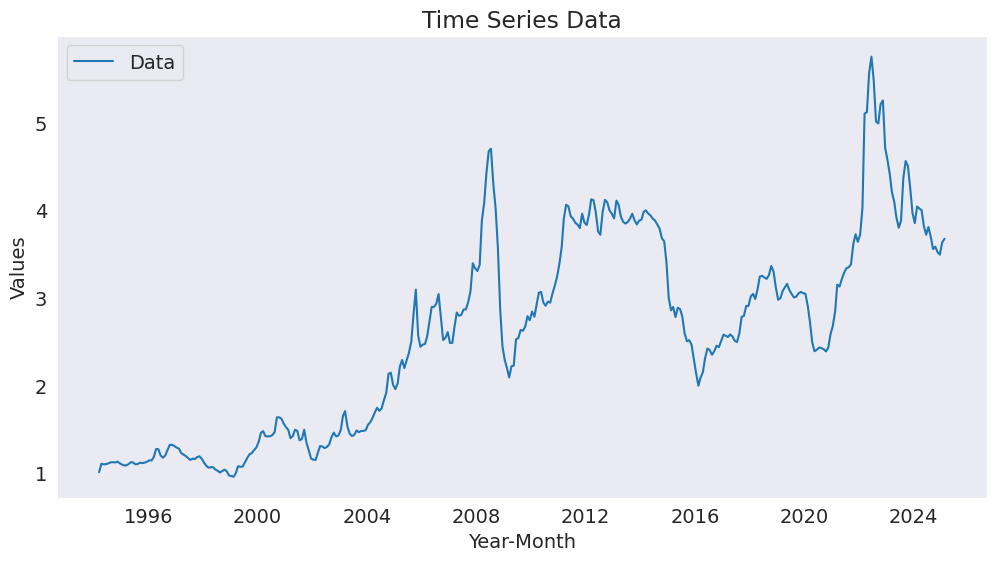

In [3]:
#Printing the data for the Years
import pandas as pd
import matplotlib.pyplot as plt


df = pd.read_csv("cleaned_file.csv", parse_dates=['date'])


df.set_index('date', inplace=True)

mean_value = df['data'].mean()
variance_value = df['data'].var()

print(f"Mean: {mean_value:.2f}")
print(f"Variance: {variance_value:.2f}")

plt.figure(figsize=(12, 6))
plt.plot(df.index, df['data'], label='Data')
plt.xlabel("Year-Month")
plt.ylabel("Values")
plt.title("Time Series Data")
plt.legend()
plt.grid()
plt.show()


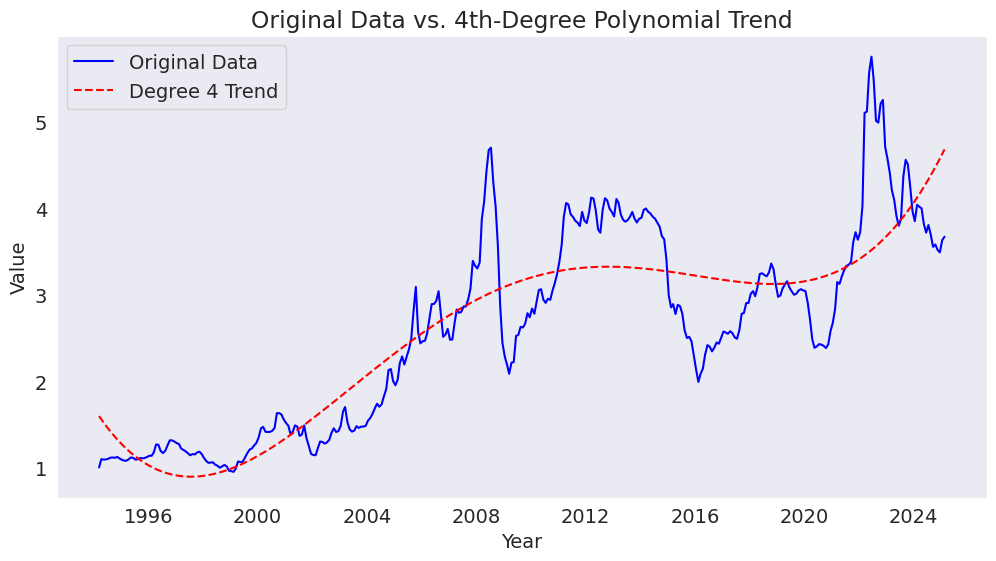

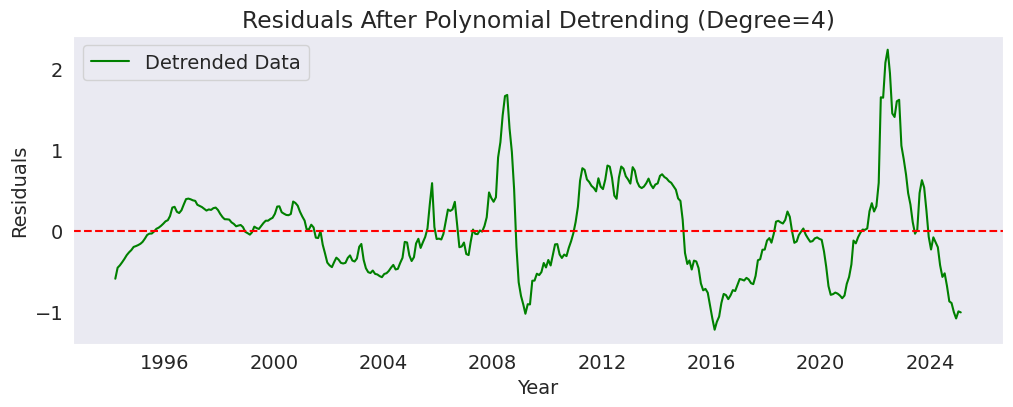

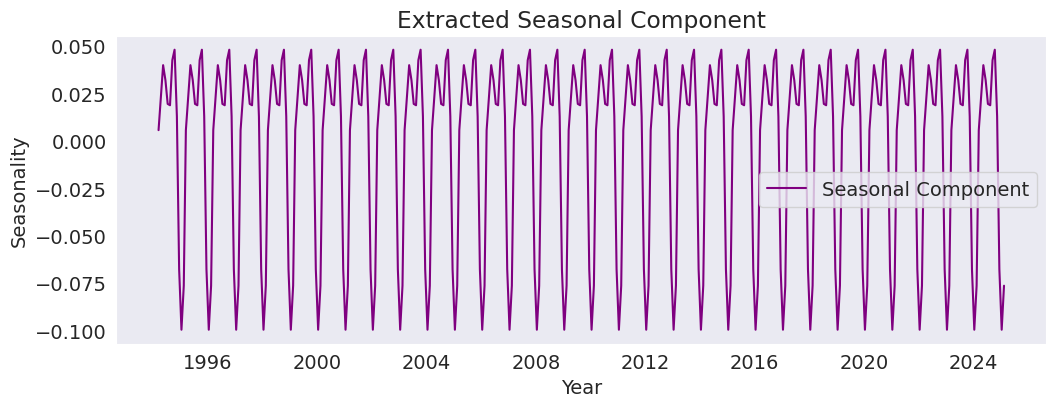

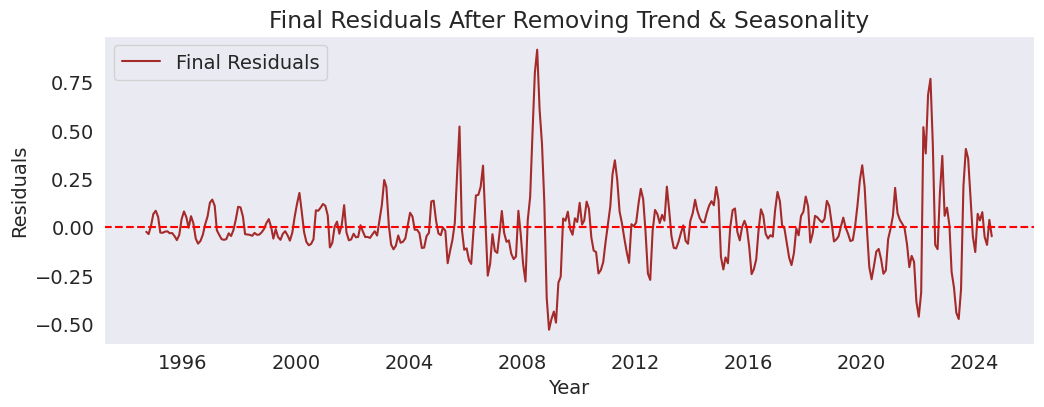

In [ ]:
# Detrending method is Polynomial
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose


df = pd.read_csv("cleaned_file.csv", parse_dates=['date'])
df.set_index('date', inplace=True)

df = df.sort_index()


df['time_index'] = (df.index - df.index.min()).days / 30.44

degree = 4
coefficients = np.polyfit(df['time_index'], df['data'], degree)
polynomial = np.poly1d(coefficients)
df['trend'] = polynomial(df['time_index'])

df['detrended'] = df['data'] - df['trend']

plt.figure(figsize=(12, 6))
plt.plot(df.index, df['data'], label='Original Data', color='blue')
plt.plot(df.index, df['trend'], label=f'Degree {degree} Trend', linestyle='--', color='red')
plt.title(f'Original Data vs. {degree}th-Degree Polynomial Trend')
plt.xlabel('Year')
plt.ylabel('Value')
plt.legend()
plt.grid()
plt.show()


plt.figure(figsize=(12, 4))
plt.plot(df.index, df['detrended'], label='Detrended Data', color='green')
plt.axhline(0, color='r', linestyle='--')
plt.title(f'Residuals After Polynomial Detrending (Degree={degree})')
plt.xlabel('Year')
plt.ylabel('Residuals')
plt.legend()
plt.grid()
plt.show()

decomposition = seasonal_decompose(df['data'], model='additive', period=12)


df['seasonal'] = decomposition.seasonal
df['residual'] = decomposition.resid

plt.figure(figsize=(12, 4))
plt.plot(df.index, df['seasonal'], label='Seasonal Component', color='purple')
plt.title('Extracted Seasonal Component')
plt.xlabel('Year')
plt.ylabel('Seasonality')
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(df.index, df['residual'], label='Final Residuals', color='brown')
plt.axhline(0, color='r', linestyle='--')
plt.title('Final Residuals After Removing Trend & Seasonality')
plt.xlabel('Year')
plt.ylabel('Residuals')
plt.legend()
plt.grid()
plt.show()




In [ ]:
# Stationarity Check
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf


residuals = df['residual'].dropna()

adf_result = adfuller(residuals)
print("ADF Test:")
print(f"  p-value: {adf_result[1]:.10f}")
print("Conclusion:", "Stationary" if adf_result[1] < 0.05 else "Non-Stationary")

kpss_result = kpss(residuals, regression='c')
print("\nKPSS Test:")
print(f"  Test Statistic: {kpss_result[0]:.4f}")
print(f"  p-value: {kpss_result[1]:.4f}")
print(f"  Critical Values: {kpss_result[3]}")
print("Conclusion:", "Non-Stationary" if kpss_result[1] < 0.05 else "Stationary")


ADF Test:
  p-value: 0.0000000015
Conclusion: Stationary

KPSS Test:
  Test Statistic: 0.0116
  p-value: 0.1000
  Critical Values: {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}
Conclusion: Stationary


<ipython-input-20-1264a28ecf3d>:13: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(residuals, regression='c')


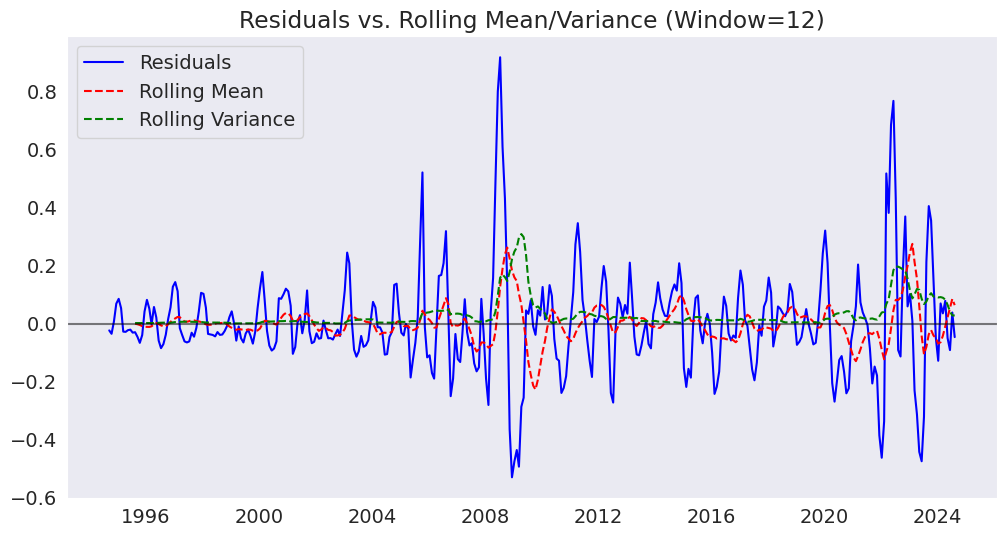

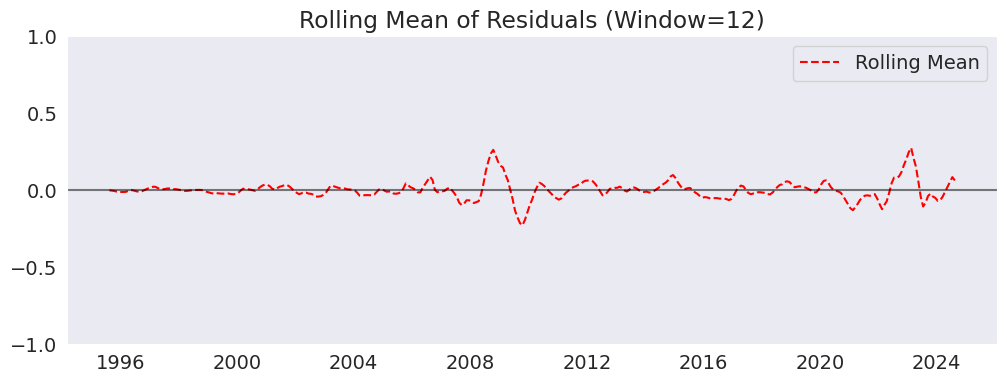

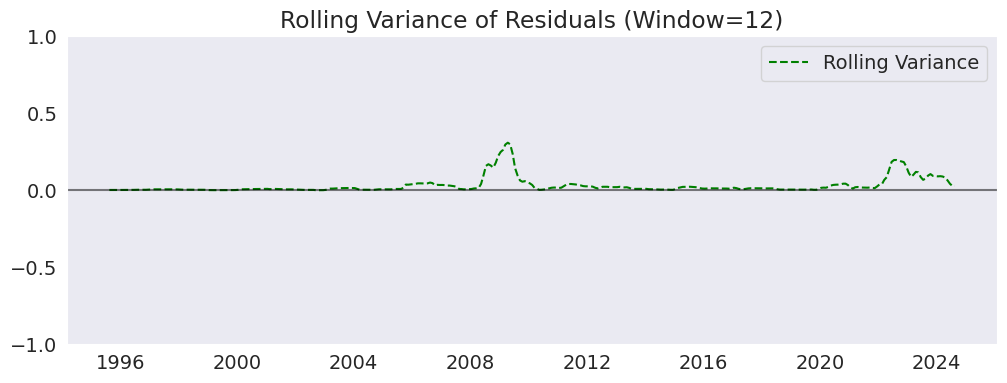

In [ ]:
# --- Rolling Mean/Variance for nomal data ---
window = 12

rolling_mean = residuals.rolling(window=window).mean()
rolling_var = residuals.rolling(window=window).var()

rolling_mean = rolling_mean.dropna()
rolling_var = rolling_var.dropna()

plt.figure(figsize=(12, 6))
plt.plot(residuals, label='Residuals', color='blue')
plt.plot(rolling_mean, label='Rolling Mean', color='red', linestyle='--')
plt.plot(rolling_var, label='Rolling Variance', color='green', linestyle='--')
plt.axhline(0, color='black', linestyle='-', alpha=0.5)
plt.title('Residuals vs. Rolling Mean/Variance (Window=12)')
plt.legend()
plt.grid()
plt.show()

# Plot Rolling Mean
plt.figure(figsize=(12, 4))
plt.plot(rolling_mean, label='Rolling Mean', color='red', linestyle='--')
plt.axhline(0, color='black', linestyle='-', alpha=0.5)
plt.title('Rolling Mean of Residuals (Window=12)')
plt.ylim(-1, 1)
plt.legend()
plt.grid()
plt.show()

# Plot Rolling Variance
plt.figure(figsize=(12, 4))
plt.plot(rolling_var, label='Rolling Variance', color='green', linestyle='--')
plt.axhline(0, color='black', linestyle='-', alpha=0.5)
plt.title('Rolling Variance of Residuals (Window=12)')
plt.ylim(-1, 1)
plt.legend()
plt.grid()
plt.show()


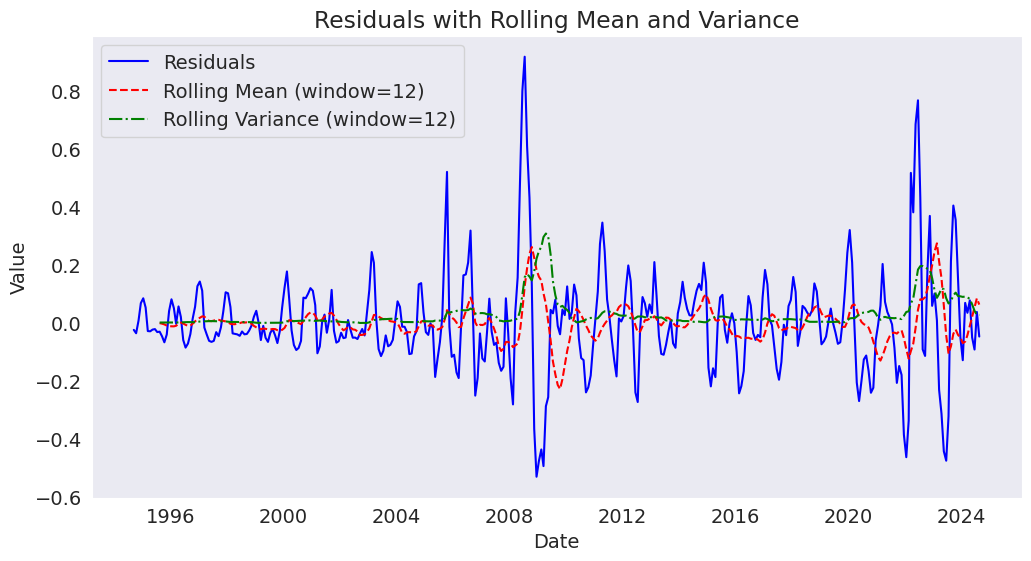

Identified Outliers in Residuals:
            residual
date                
2008-06-15  0.800940
2008-07-15  0.918903
2008-08-15  0.610201
2008-12-15 -0.530021
2022-05-15  0.685896
2022-06-15  0.768482


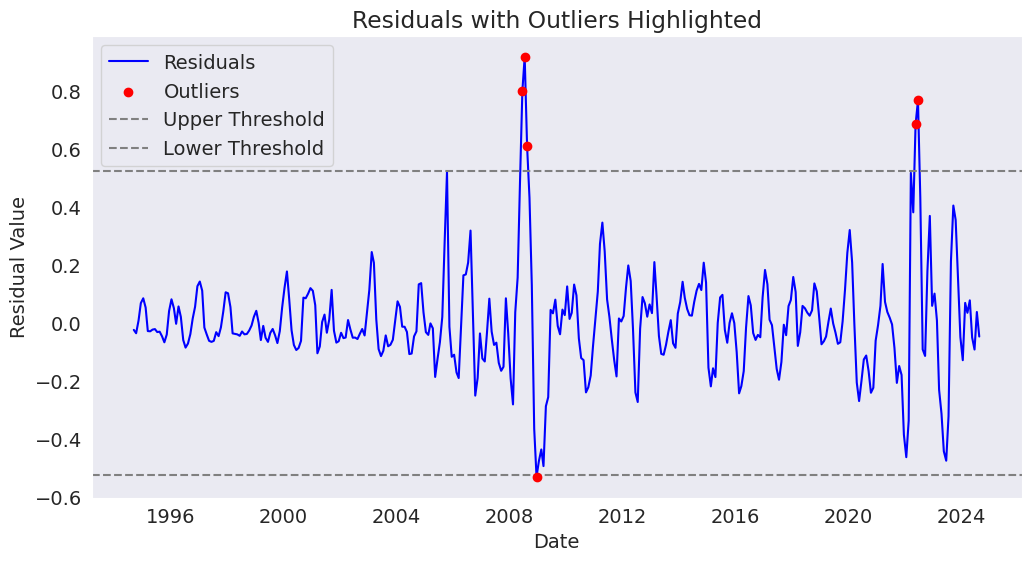

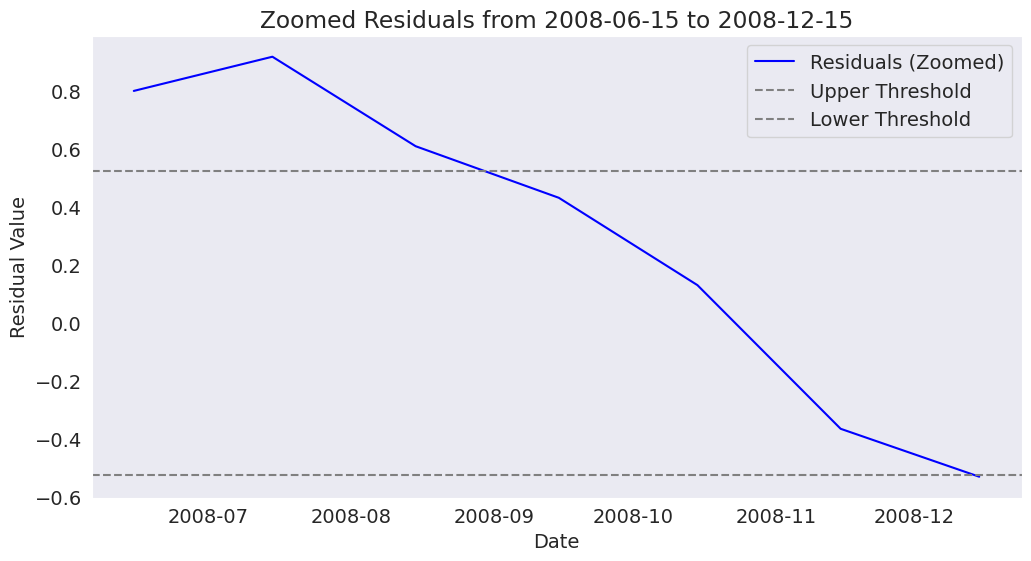

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------
# 1. Compute Rolling Statistics
# ---------------------------

window_size = 12

df['rolling_mean'] = df['residual'].rolling(window=window_size).mean()
df['rolling_var'] = df['residual'].rolling(window=window_size).var()


plt.figure(figsize=(12, 6))
plt.plot(df.index, df['residual'], label='Residuals', color='blue')
plt.plot(df.index, df['rolling_mean'], label=f'Rolling Mean (window={window_size})', color='red', linestyle='--')
plt.plot(df.index, df['rolling_var'], label=f'Rolling Variance (window={window_size})', color='green', linestyle='-.')
plt.title('Residuals with Rolling Mean and Variance')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.grid()
plt.show()

# ---------------------------
# 2. Identify Outliers in Residuals
# ---------------------------

resid_mean = df['residual'].mean()
resid_std = df['residual'].std()

upper_threshold = resid_mean + 3 * resid_std
lower_threshold = resid_mean - 3 * resid_std

df['outlier'] = (df['residual'] > upper_threshold) | (df['residual'] < lower_threshold)

outliers = df[df['outlier']]
print("Identified Outliers in Residuals:")
print(outliers[['residual']])


plt.figure(figsize=(12, 6))
plt.plot(df.index, df['residual'], label='Residuals', color='blue')
plt.scatter(outliers.index, outliers['residual'], color='red', label='Outliers', zorder=5)
plt.axhline(upper_threshold, color='gray', linestyle='--', label='Upper Threshold')
plt.axhline(lower_threshold, color='gray', linestyle='--', label='Lower Threshold')
plt.title('Residuals with Outliers Highlighted')
plt.xlabel('Date')
plt.ylabel('Residual Value')
plt.legend()
plt.grid()
plt.show()

# ---------------------------
# 3. Zoom In on Specific Time Period for Detailed Analysis
# ---------------------------

zoom_start = '2008-06-15'
zoom_end = '2008-12-15'

df_zoom = df.loc[zoom_start:zoom_end]


plt.figure(figsize=(12, 6))
plt.plot(df_zoom.index, df_zoom['residual'], label='Residuals (Zoomed)', color='blue')
plt.axhline(upper_threshold, color='gray', linestyle='--', label='Upper Threshold')
plt.axhline(lower_threshold, color='gray', linestyle='--', label='Lower Threshold')
plt.title(f'Zoomed Residuals from {zoom_start} to {zoom_end}')
plt.xlabel('Date')
plt.ylabel('Residual Value')
plt.legend()
plt.grid()
plt.show()


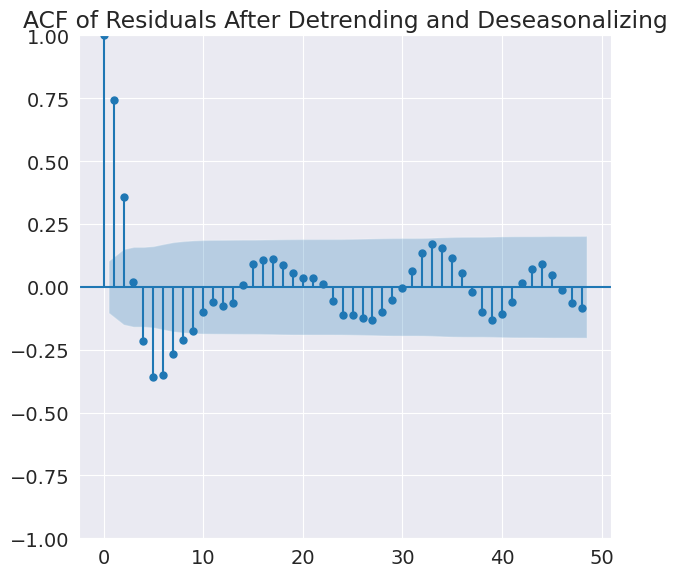

In [ ]:
#ACF and PACF for log residual data
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plot_acf(df['residual'].dropna(), lags=48, ax=plt.gca())
plt.title('ACF of Residuals After Detrending and Deseasonalizing')

# plt.subplot(1, 2, 2)
# plot_pacf(df['residual'].dropna(), lags=24, ax=plt.gca())
# plt.title('PACF of Residuals After Detrending and Deseasonalizing')

plt.tight_layout()
plt.show()



/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                      
Dep. Variable:                               data   No. Observations:                  372
Model:             SARIMAX(1, 0, 1)x(1, 1, 1, 12)   Log Likelihood                 192.621
Date:                            Sun, 13 Apr 2025   AIC                           -375.243
Time:                                    05:49:58   BIC                           -356.011
Sample:                                         0   HQIC                          -367.585
                                            - 372                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9872      0.006    170.603      0.000       0.976       0.999
ma.L1          0.3881      0.029   

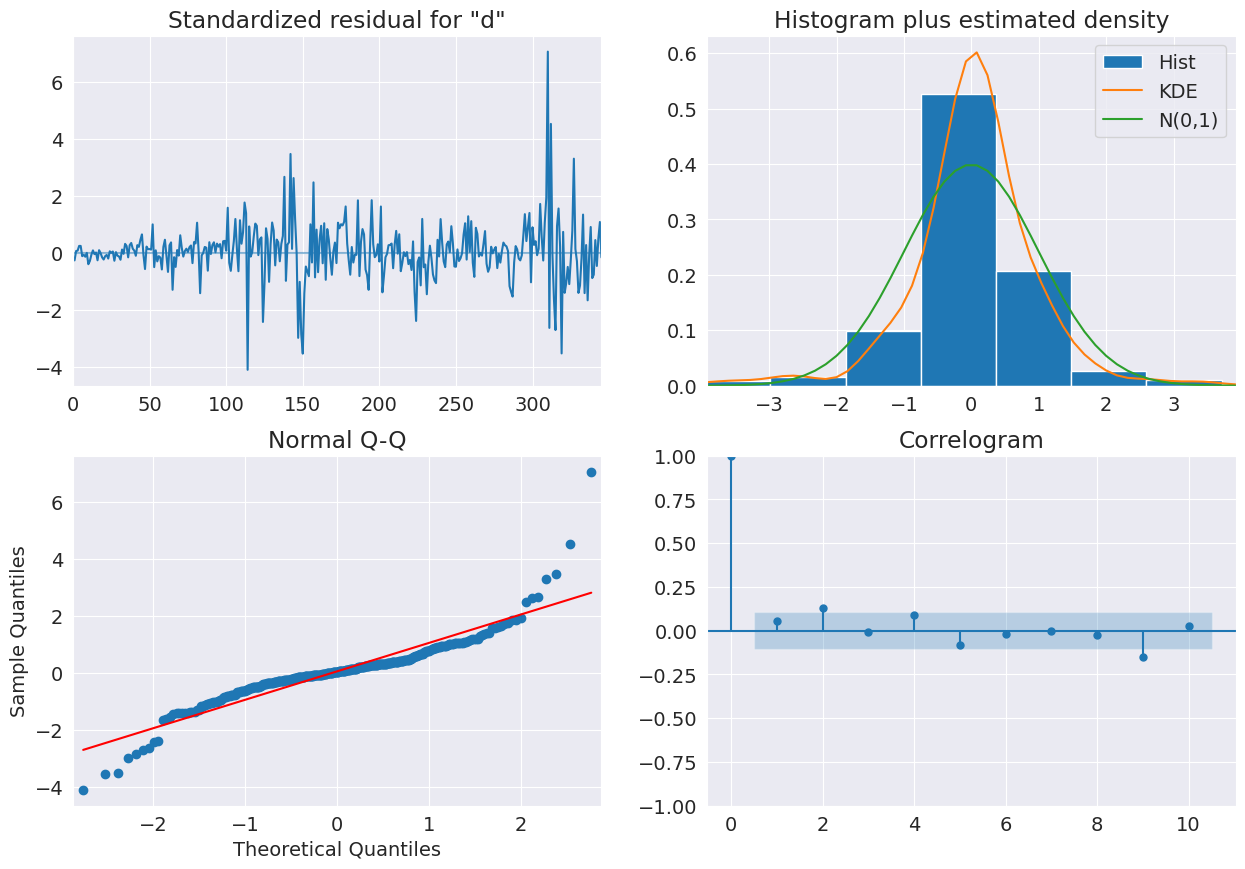

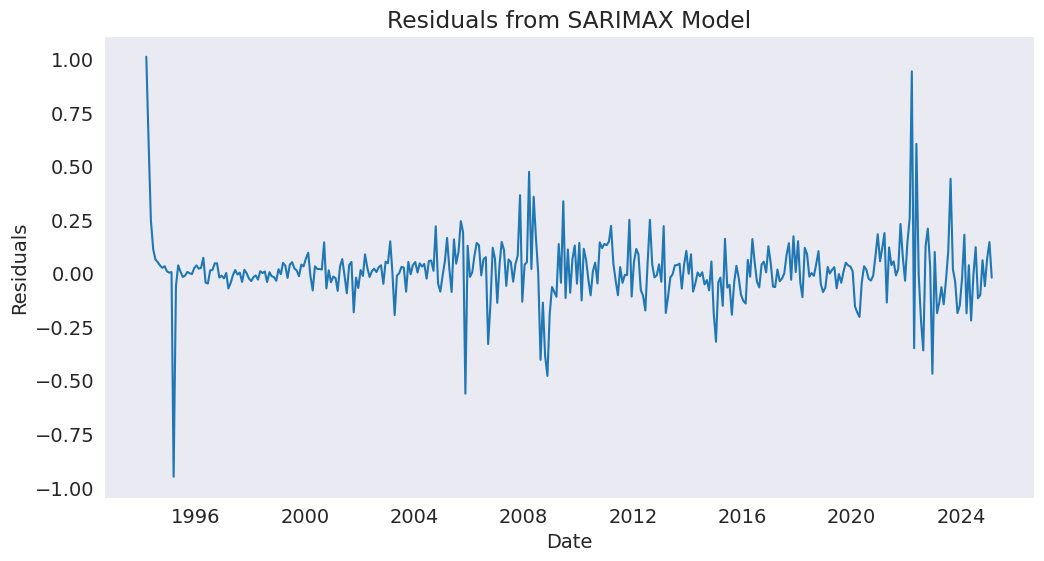

<Figure size 1200x600 with 0 Axes>

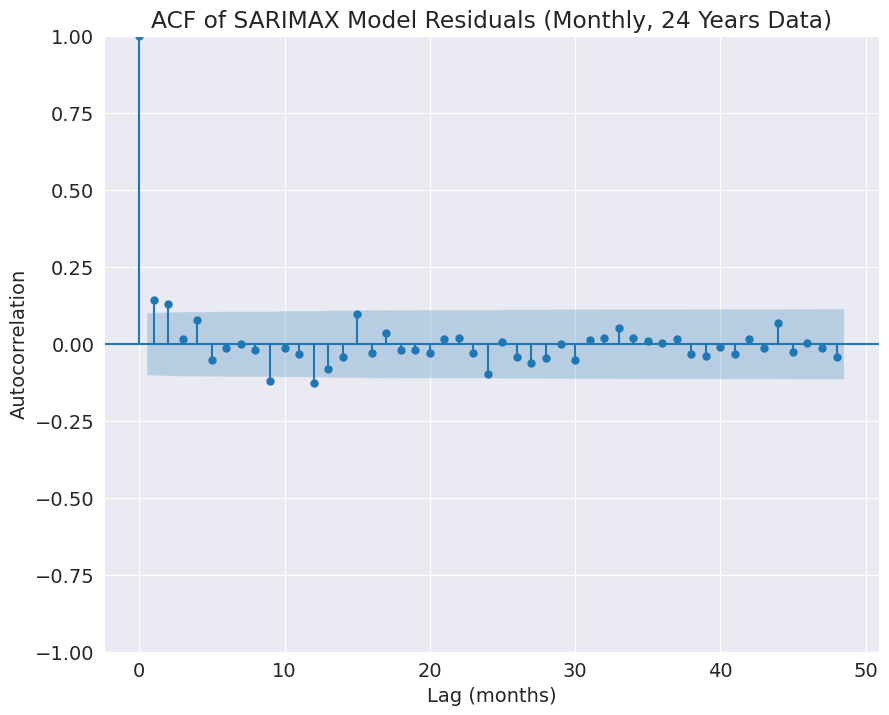

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf
import statsmodels.api as sm



# ---------------------------
# 1. Fit a SARIMAX Model
# ---------------------------
model = SARIMAX(df['data'],
                order=(1, 0, 1),
                seasonal_order=(1, 1, 1, 12),
                enforce_stationarity=False,
                enforce_invertibility=False)

model_fit = model.fit(disp=False)
print(model_fit.summary())

# ---------------------------
# 2. Diagnostic Plots
# ---------------------------

model_fit.plot_diagnostics(figsize=(15, 10))
plt.show()

# ---------------------------
# 3. Check Residuals and Their ACF
# ---------------------------

residuals = model_fit.resid
plt.figure(figsize=(12, 6))
plt.plot(residuals)
plt.title('Residuals from SARIMAX Model')
plt.xlabel('Date')
plt.ylabel('Residuals')
plt.grid()
plt.show()


plt.figure(figsize=(12, 6))
plot_acf(residuals, lags=48, alpha=0.05)
plt.title('ACF of SARIMAX Model Residuals (Monthly, 24 Years Data)')
plt.xlabel('Lag (months)')
plt.ylabel('Autocorrelation')
plt.show()


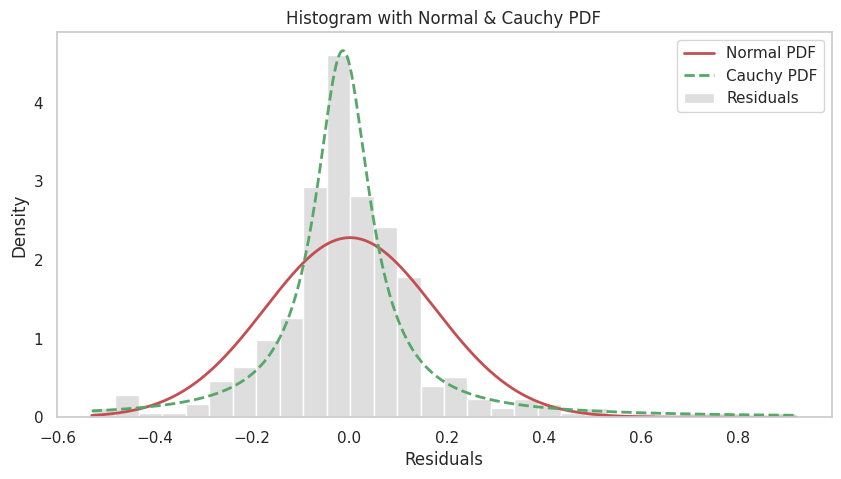

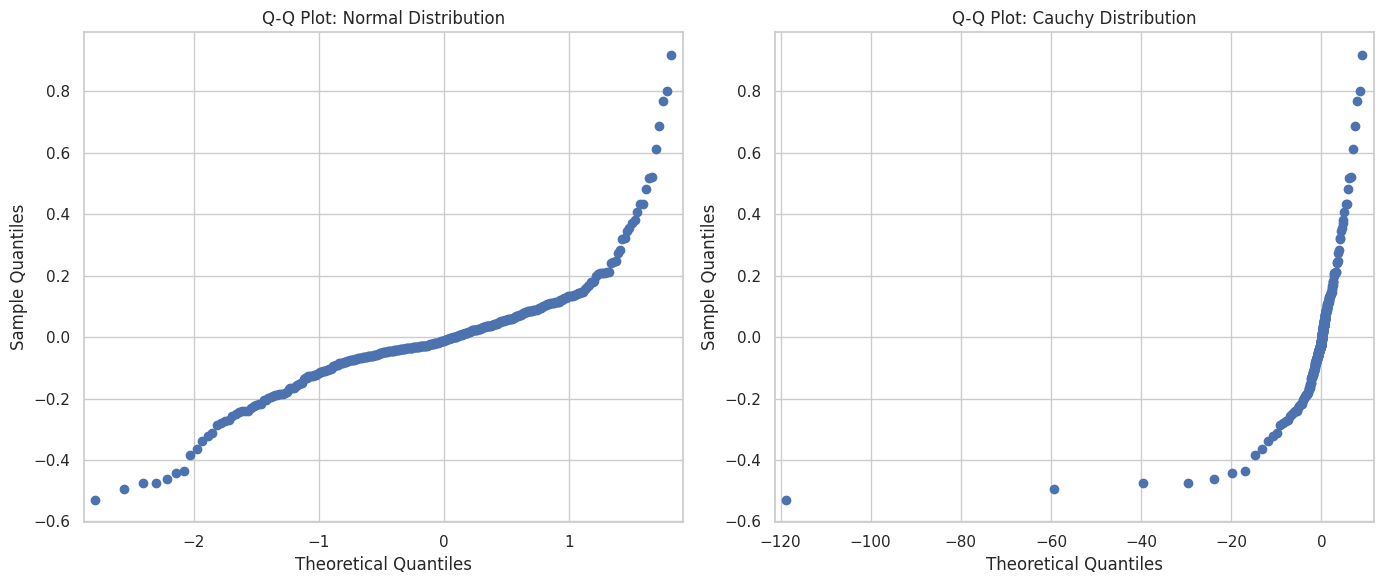

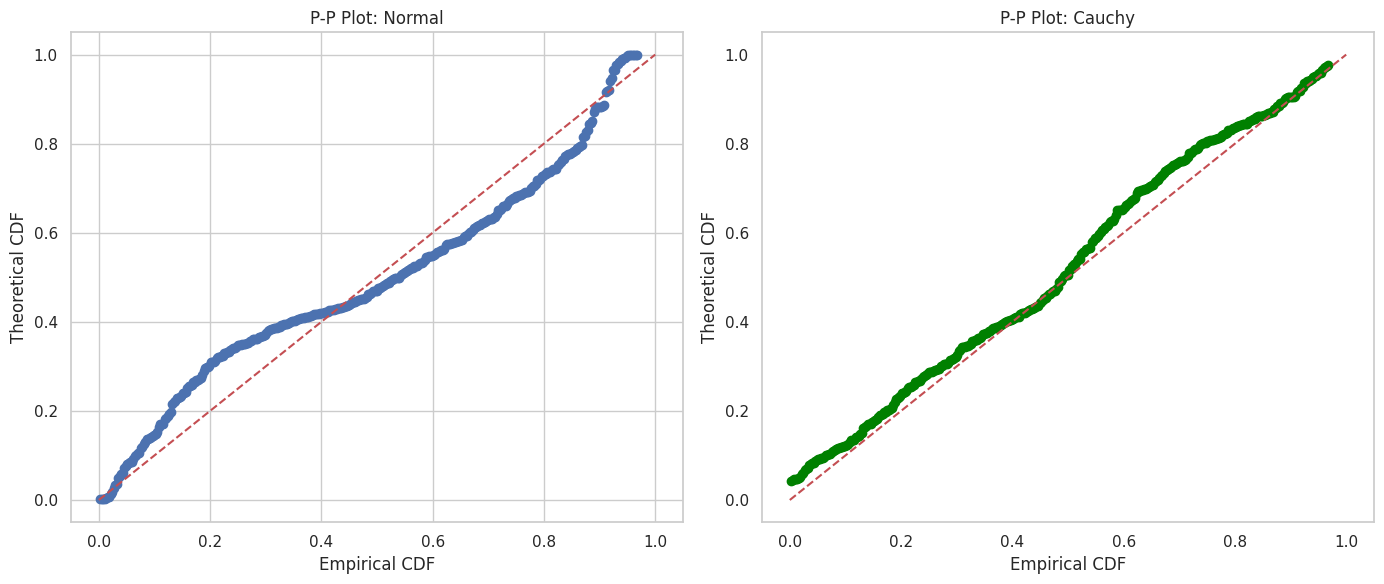

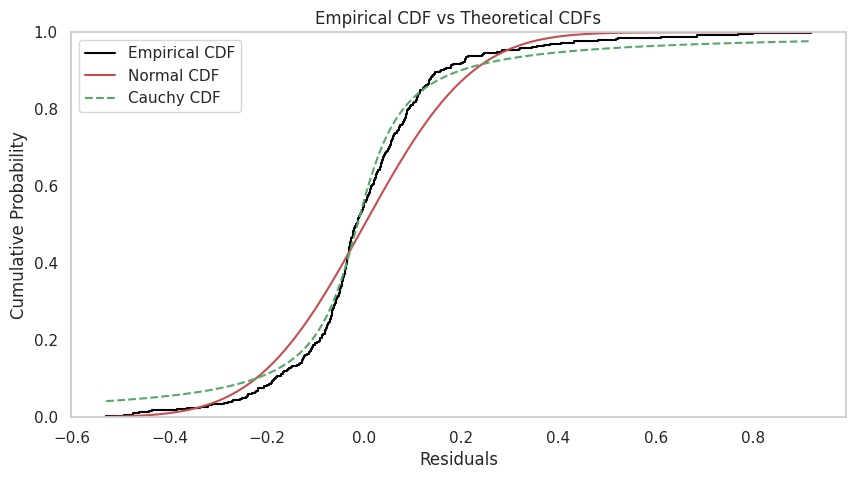

K-S Test for Normal: KstestResult(statistic=np.float64(0.10645734460451284), pvalue=np.float64(0.0005242498187971599), statistic_location=np.float64(0.11530277777777835), statistic_sign=np.int8(1))
K-S Test for Cauchy: KstestResult(statistic=np.float64(0.048508500961447654), pvalue=np.float64(0.35386022210997914), statistic_location=np.float64(0.03285416666666731), statistic_sign=np.int8(-1))


In [ ]:
#distribution Fitting
import seaborn as sns
from scipy import stats
import matplotlib.pyplot as plt


residuals = df['residual']
sns.set(style="whitegrid")


residuals_clean = residuals[np.isfinite(residuals)]


mean, std = residuals_clean.mean(), residuals_clean.std()
params_cauchy = stats.cauchy.fit(residuals_clean)


xmin, xmax = residuals_clean.min(), residuals_clean.max()
x = np.linspace(xmin, xmax, 500)

# -------------------------------
# 1. Histogram with PDF overlays
# -------------------------------

plt.figure(figsize=(10, 5))
sns.histplot(residuals, kde=False, bins=30, stat="density", color='lightgray', label="Residuals")
plt.plot(x, stats.norm.pdf(x, mean, std), 'r-', lw=2, label='Normal PDF')
plt.plot(x, stats.cauchy.pdf(x, *params_cauchy), 'g--', lw=2, label='Cauchy PDF')
plt.title("Histogram with Normal & Cauchy PDF")
plt.xlabel("Residuals")
plt.ylabel("Density")
plt.legend()
plt.grid()
plt.show()

# -------------------------------
# 2. Q-Q Plots
# -------------------------------

fig, ax = plt.subplots(1, 2, figsize=(14, 6))

sm.qqplot(residuals, line='s', dist=stats.norm, ax=ax[0])
ax[0].set_title('Q-Q Plot: Normal Distribution')

sm.qqplot(residuals, line='s', dist=stats.cauchy, ax=ax[1])
ax[1].set_title('Q-Q Plot: Cauchy Distribution')

plt.tight_layout()
plt.show()

# -------------------------------
# 3. P-P Plots
# -------------------------------

fig, ax = plt.subplots(1, 2, figsize=(14, 6))
residuals_sorted = np.sort(residuals)
n = len(residuals_sorted)
p_empirical = np.arange(1, n + 1) / n

p_normal = stats.norm.cdf(residuals_sorted, mean, std)
p_cauchy = stats.cauchy.cdf(residuals_sorted, *params_cauchy)

ax[0].plot(p_empirical, p_normal, 'o', label="P-P Normal")
ax[0].plot([0, 1], [0, 1], 'r--')
ax[0].set_title('P-P Plot: Normal')
ax[0].set_xlabel("Empirical CDF")
ax[0].set_ylabel("Theoretical CDF")

ax[1].plot(p_empirical, p_cauchy, 'o', label="P-P Cauchy", color='green')
ax[1].plot([0, 1], [0, 1], 'r--')
ax[1].set_title('P-P Plot: Cauchy')
ax[1].set_xlabel("Empirical CDF")
ax[1].set_ylabel("Theoretical CDF")

plt.tight_layout()
plt.grid()
plt.show()

# -------------------------------
# 4. CDF Overlay with Empirical CDF
# -------------------------------

plt.figure(figsize=(10, 5))
sns.ecdfplot(residuals, label='Empirical CDF', color='black')
plt.plot(x, stats.norm.cdf(x, mean, std), 'r-', label='Normal CDF')
plt.plot(x, stats.cauchy.cdf(x, *params_cauchy), 'g--', label='Cauchy CDF')
plt.title("Empirical CDF vs Theoretical CDFs")
plt.xlabel("Residuals")
plt.ylabel("Cumulative Probability")
plt.legend()
plt.grid()
plt.show()

from scipy.stats import kstest

# Kolmogorov-Smirnov Test
ks_norm = kstest(residuals_clean, 'norm', args=(mean, std))
ks_cauchy = kstest(residuals_clean, 'cauchy', args=params_cauchy)

print("K-S Test for Normal:", ks_norm)
print("K-S Test for Cauchy:", ks_cauchy)


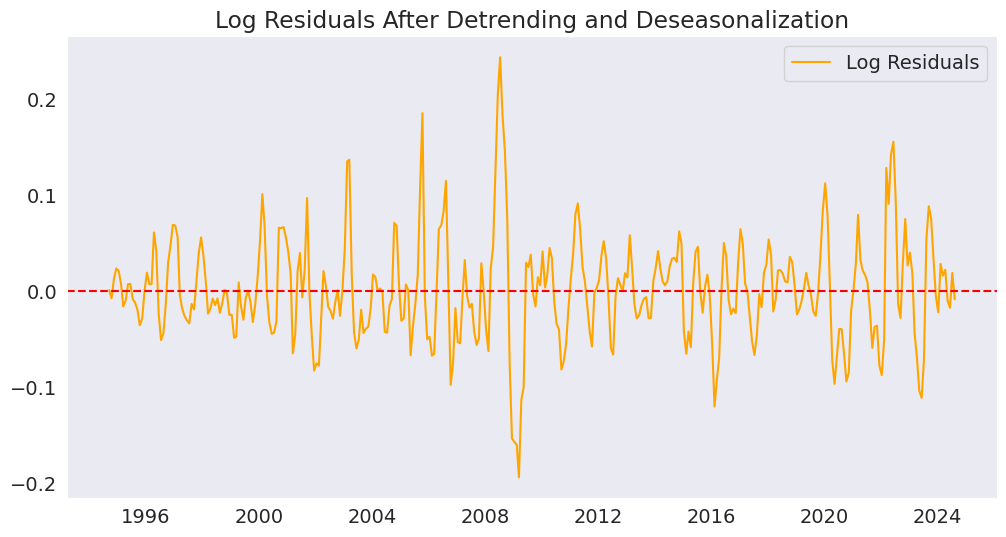

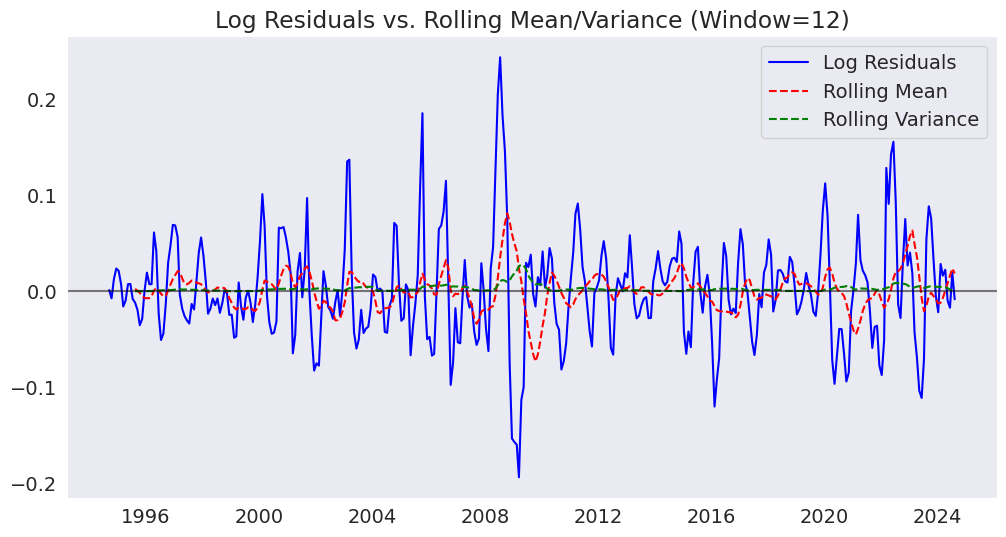

Index(['data', 'year_month', 'time_index', 'trend', 'detrended', 'seasonal',
       'residual', 'rolling_mean', 'rolling_var', 'outlier', 'log_data',
       'log_detrended', 'log_seasonal', 'log_residual'],
      dtype='object')


In [ ]:
# Rolloing mean and variance for Log normal data ----
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df['log_data'] = np.log(df['data'])

time_index = (df.index.year - df.index.year.min()) * 12 + df.index.month

degree =  4
coefficients = np.polyfit(time_index, df['log_data'], degree)
polynomial = np.poly1d(coefficients)
trend = polynomial(time_index)
df['log_detrended'] = df['log_data'] - trend


from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(
    df['log_detrended'].dropna(),
    model='additive',
    period=12
)

df['log_seasonal'] = decomposition.seasonal
df['log_residual'] = decomposition.resid

plt.figure(figsize=(12, 6))
plt.plot(df.index, df['log_residual'], label='Log Residuals', color='orange')
plt.axhline(0, color='r', linestyle='--')
plt.title('Log Residuals After Detrending and Deseasonalization')
plt.legend()
plt.grid()
plt.show()


window = 12
rolling_mean = df['log_residual'].rolling(window=window).mean()
rolling_var = df['log_residual'].rolling(window=window).var()


plt.figure(figsize=(12, 6))
plt.plot(df['log_residual'], label='Log Residuals', color='blue')
plt.plot(rolling_mean, label='Rolling Mean', color='red', linestyle='--')
plt.plot(rolling_var, label='Rolling Variance', color='green', linestyle='--')
plt.axhline(0, color='black', linestyle='-', alpha=0.5)
plt.title('Log Residuals vs. Rolling Mean/Variance (Window=12)')
plt.legend()
plt.grid()
plt.show()
print(df.columns)

In [ ]:
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import datetime
import plotly.express as px
from wordcloud import WordCloud
from collections import Counter
from typing import List
import matplotlib.gridspec as gridspec
%matplotlib inline
sns.set_style('darkgrid')
matplotlib.rcParams['font.size']=14
matplotlib.rcParams['figure.figsize'] = (10,8)
pd.set_option('display.max_columns', None)


file_path = '/content/gdrive/MyDrive/railway_prices(data).csv'

df2 = pd.read_csv(file_path)
df2['year_month'] = pd.to_datetime(df2['year_month'], format='%Y %b', errors='coerce')


df2.to_csv("cleaned_file.csv", index=False)

df2.head()

,year_month,data
0,1987-02-01,100.0
1,1987-03-01,100.1
2,1987-04-01,100.1
3,1987-05-01,100.1
4,1987-06-01,100.1


Mean: 2.59
Variance: 1.28


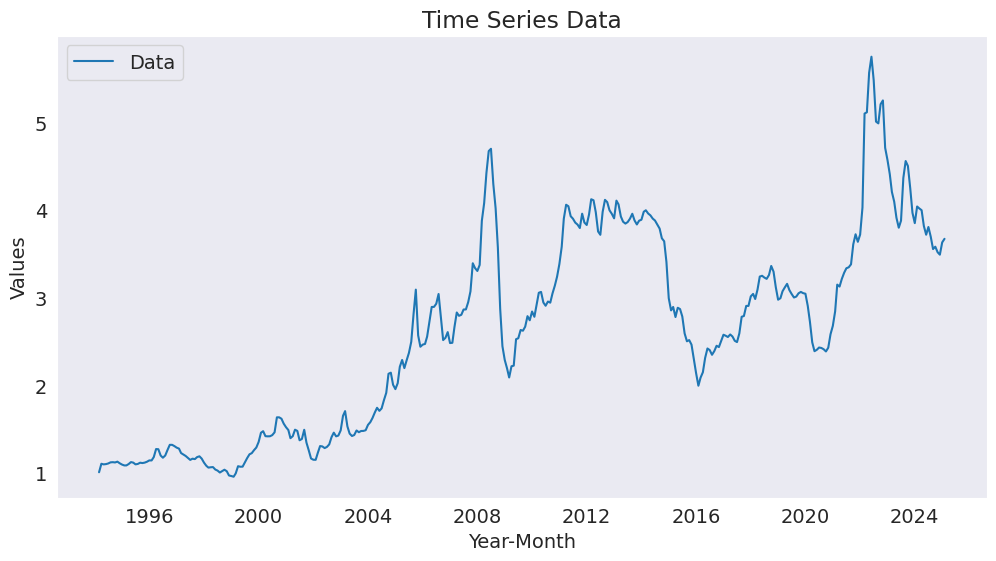

In [ ]:
#Printing the data for the Years
import pandas as pd
import matplotlib.pyplot as plt


df2 = pd.read_csv("cleaned_file.csv", parse_dates=['year_month'])

df2.set_index('year_month', inplace=True)

mean_value = df2['data'].mean()
variance_value = df2['data'].var()

print(f"Mean: {mean_value:.2f}")

print(f"Variance: {variance_value:.2f}")

plt.figure(figsize=(12, 6))
plt.plot(df2.index, df2['data'], label='Data')
plt.xlabel("Year-Month")
plt.ylabel("Values")
plt.title("Time Series Data")
plt.legend()
plt.grid()
plt.show()


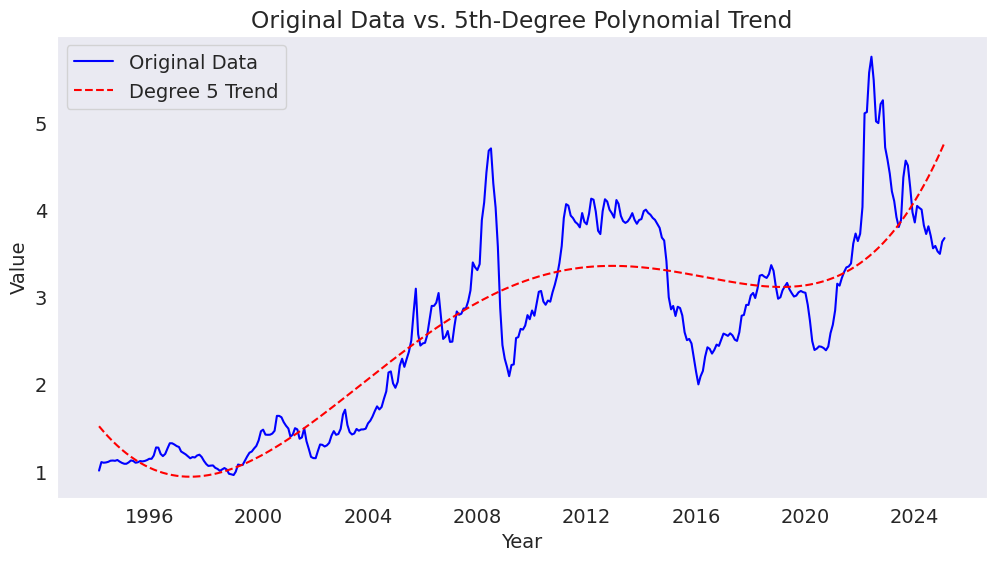

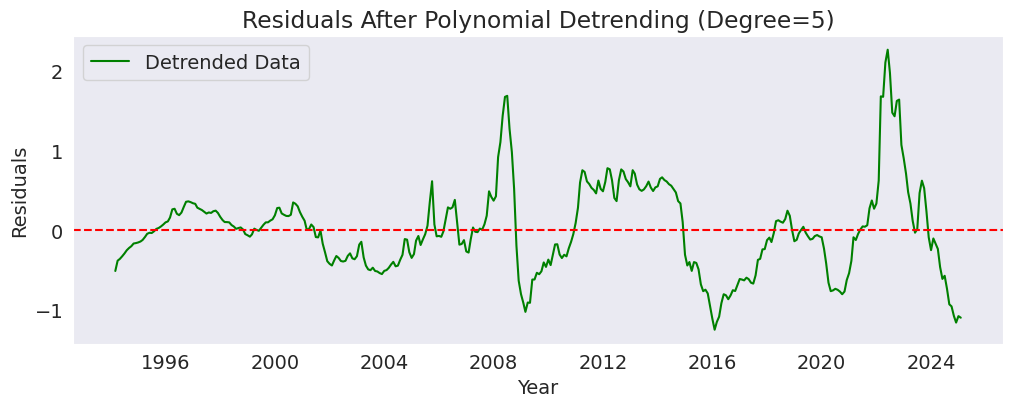

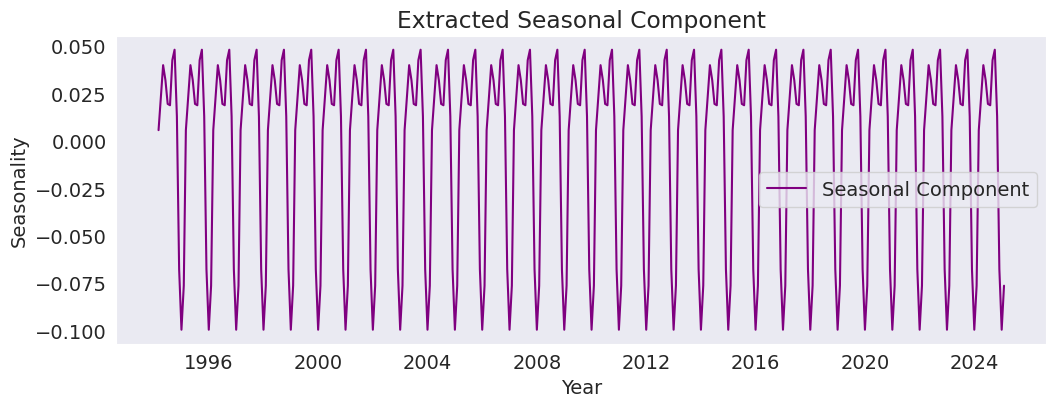

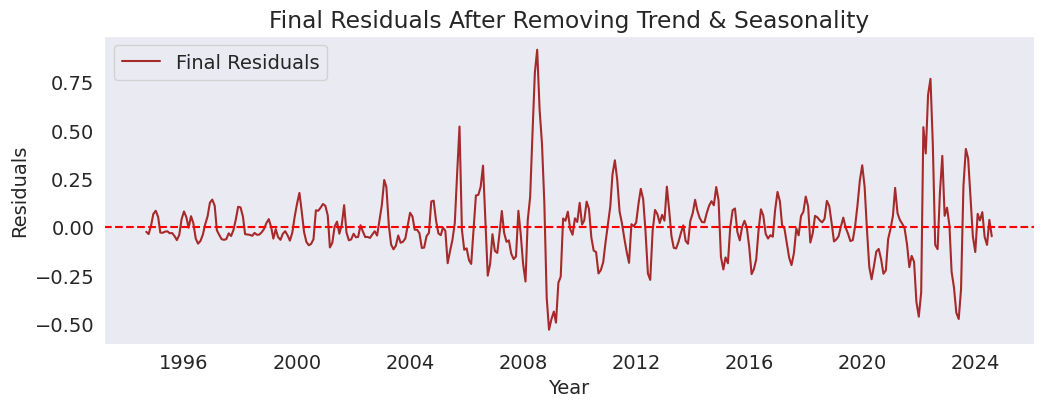

In [ ]:
# Detrending method is Polynomial
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose


df2 = pd.read_csv("cleaned_file.csv", parse_dates=['year_month'])
df2.set_index('year_month', inplace=True)

df2 = df2.sort_index()


df2['time_index'] = (df2.index - df2.index.min()).days / 30.44

degree = 5
coefficients = np.polyfit(df2['time_index'], df2['data'], degree)
polynomial = np.poly1d(coefficients)
df2['trend'] = polynomial(df2['time_index'])


df2['detrended'] = df2['data'] - df2['trend']

plt.figure(figsize=(12, 6))
plt.plot(df2.index, df2['data'], label='Original Data', color='blue')
plt.plot(df2.index, df2['trend'], label=f'Degree {degree} Trend', linestyle='--', color='red')
plt.title(f'Original Data vs. {degree}th-Degree Polynomial Trend')
plt.xlabel('Year')
plt.ylabel('Value')
plt.legend()
plt.grid()
plt.show()


plt.figure(figsize=(12, 4))
plt.plot(df2.index, df2['detrended'], label='Detrended Data', color='green')
plt.axhline(0, color='r', linestyle='--')
plt.title(f'Residuals After Polynomial Detrending (Degree={degree})')
plt.xlabel('Year')
plt.ylabel('Residuals')
plt.legend()
plt.grid()
plt.show()

decomposition = seasonal_decompose(df2['data'], model='additive', period=12)


df2['seasonal'] = decomposition.seasonal
df2['poly_residual'] = decomposition.resid

plt.figure(figsize=(12, 4))
plt.plot(df2.index, df2['seasonal'], label='Seasonal Component', color='purple')
plt.title('Extracted Seasonal Component')
plt.xlabel('Year')
plt.ylabel('Seasonality')
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(df2.index, df2['poly_residual'], label='Final Residuals', color='brown')
plt.axhline(0, color='r', linestyle='--')
plt.title('Final Residuals After Removing Trend & Seasonality')
plt.xlabel('Year')
plt.ylabel('Residuals')
plt.legend()
plt.grid()
plt.show()




In [ ]:
# Stationarity Check
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf


residuals = df2['poly_residual'].dropna()


adf_result = adfuller(residuals)
print("ADF Test:")
print(f"  p-value: {adf_result[1]:.12f}")
print("Conclusion:", "Stationary" if adf_result[1] < 0.05 else "Non-Stationary")


kpss_result = kpss(residuals, regression='c')
print("\nKPSS Test:")
print(f"  Test Statistic: {kpss_result[0]:.4f}")
print(f"  p-value: {kpss_result[1]:.4f}")
print(f"  Critical Values: {kpss_result[3]}")
print("Conclusion:", "Non-Stationary" if kpss_result[1] < 0.05 else "Stationary")


ADF Test:
  p-value: 0.000000001523
Conclusion: Stationary

KPSS Test:
  Test Statistic: 0.0116
  p-value: 0.1000
  Critical Values: {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}
Conclusion: Stationary


<ipython-input-18-630f2fcc475a>:15: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(residuals, regression='c')


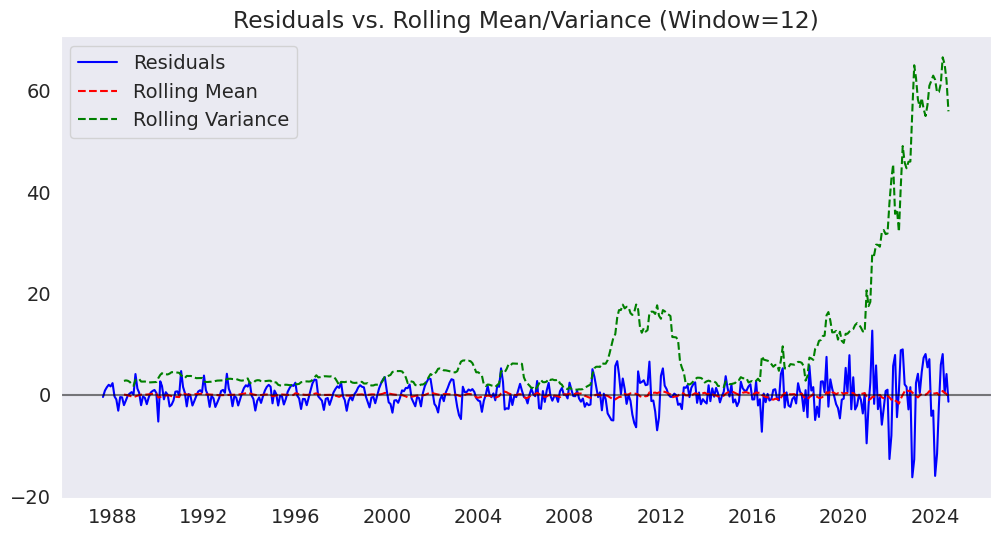

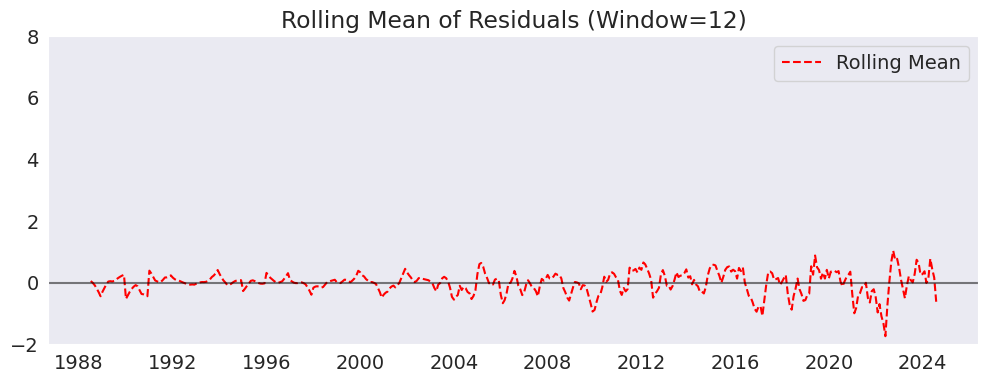

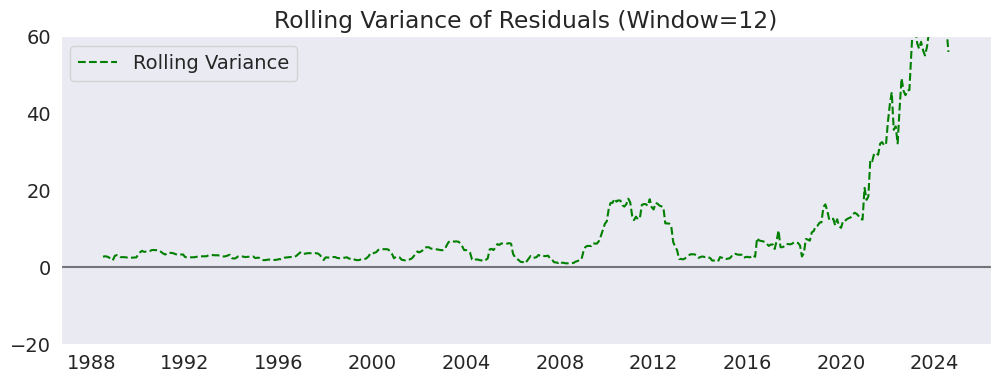

In [ ]:
# --- Rolling Mean/Variance for nomal data ---
window = 12

rolling_mean = residuals.rolling(window=window).mean()
rolling_var = residuals.rolling(window=window).var()


rolling_mean = rolling_mean.dropna()
rolling_var = rolling_var.dropna()


plt.figure(figsize=(12, 6))
plt.plot(residuals, label='Residuals', color='blue')
plt.plot(rolling_mean, label='Rolling Mean', color='red', linestyle='--')
plt.plot(rolling_var, label='Rolling Variance', color='green', linestyle='--')
plt.axhline(0, color='black', linestyle='-', alpha=0.5)
plt.title('Residuals vs. Rolling Mean/Variance (Window=12)')
plt.legend()
plt.grid()
plt.show()


plt.figure(figsize=(12, 4))
plt.plot(rolling_mean, label='Rolling Mean', color='red', linestyle='--')
plt.axhline(0, color='black', linestyle='-', alpha=0.5)
plt.title('Rolling Mean of Residuals (Window=12)')
plt.ylim(-2, 8)
plt.legend()
plt.grid()
plt.show()


plt.figure(figsize=(12, 4))
plt.plot(rolling_var, label='Rolling Variance', color='green', linestyle='--')
plt.axhline(0, color='black', linestyle='-', alpha=0.5)
plt.title('Rolling Variance of Residuals (Window=12)')
plt.ylim(-20, 60)
plt.legend()
plt.grid()
plt.show()


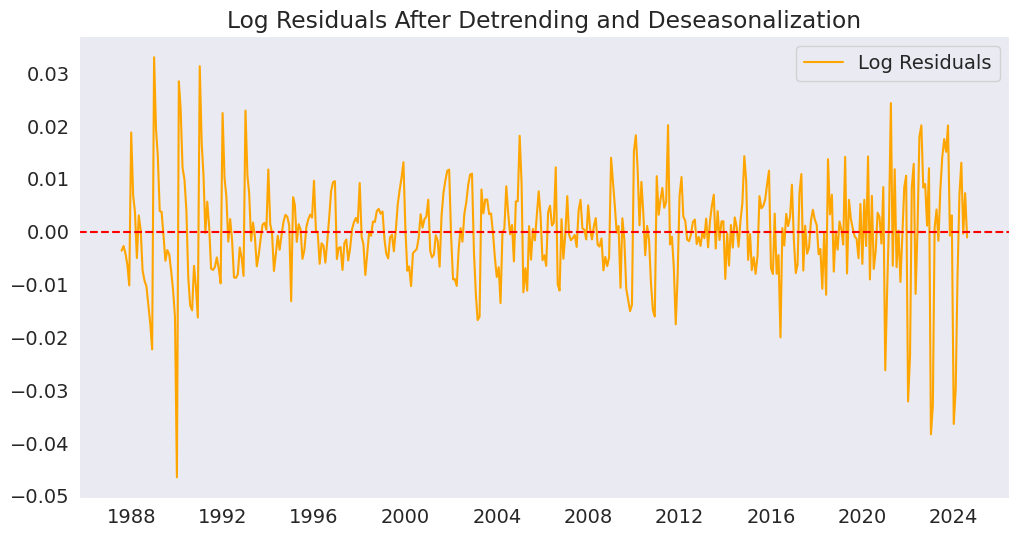

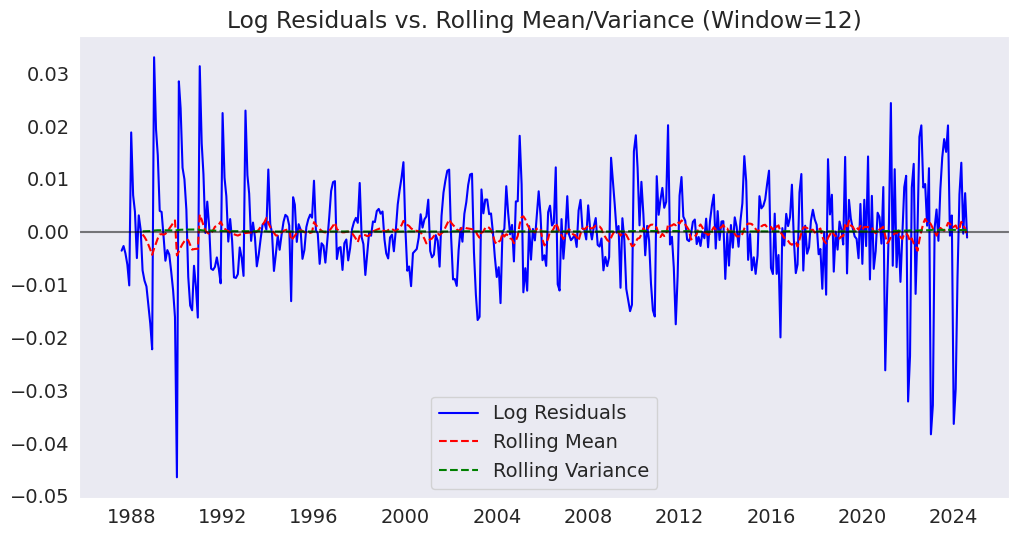

Index(['data', 'time_index', 'trend', 'detrended', 'seasonal', 'poly_residual',
       'log_data', 'log_detrended', 'log_seasonal', 'log_residual'],
      dtype='object')


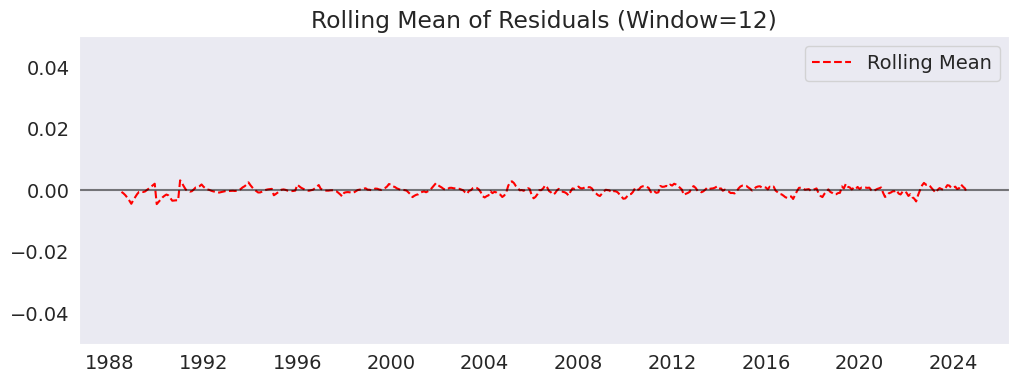

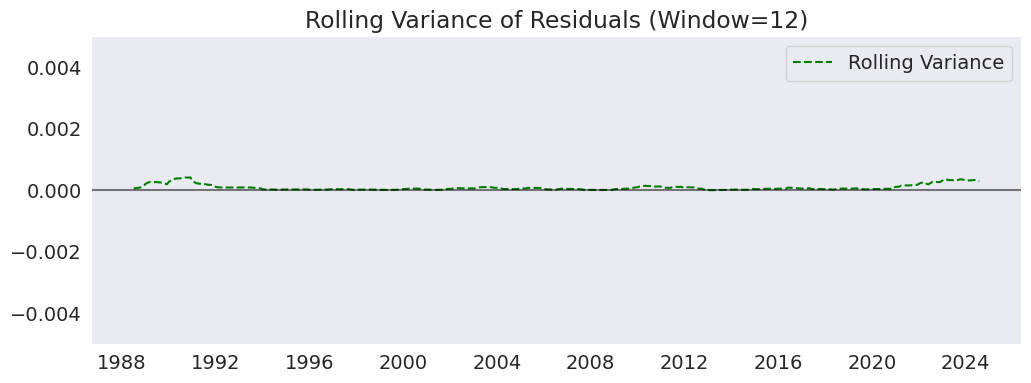

In [ ]:
# Rolloing mean and variance for Log normal data
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


df2['log_data'] = np.log(df2['data'])


time_index = (df2.index.year - df2.index.year.min()) * 12 + df2.index.month
degree = 5
coefficients = np.polyfit(time_index, df2['log_data'], degree)
polynomial = np.poly1d(coefficients)
trend = polynomial(time_index)
df2['log_detrended'] = df2['log_data'] - trend


from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(
    df2['log_detrended'].dropna(),
    model='additive',
    period=12
)

df2['log_seasonal'] = decomposition.seasonal
df2['log_residual'] = decomposition.resid


plt.figure(figsize=(12, 6))
plt.plot(df2.index, df2['log_residual'], label='Log Residuals', color='orange')
plt.axhline(0, color='r', linestyle='--')
plt.title('Log Residuals After Detrending and Deseasonalization')
plt.legend()
plt.grid()
plt.show()


window = 12
rolling_mean = df2['log_residual'].rolling(window=window).mean()
rolling_var = df2['log_residual'].rolling(window=window).var()


plt.figure(figsize=(12, 6))
plt.plot(df2['log_residual'], label='Log Residuals', color='blue')
plt.plot(rolling_mean, label='Rolling Mean', color='red', linestyle='--')
plt.plot(rolling_var, label='Rolling Variance', color='green', linestyle='--')
plt.axhline(0, color='black', linestyle='-', alpha=0.5)
plt.title('Log Residuals vs. Rolling Mean/Variance (Window=12)')
plt.legend()
plt.grid()
plt.show()
print(df2.columns)

plt.figure(figsize=(12, 4))
plt.plot(rolling_mean, label='Rolling Mean', color='red', linestyle='--')
plt.axhline(0, color='black', linestyle='-', alpha=0.5)
plt.title('Rolling Mean of Residuals (Window=12)')
plt.ylim(-0.05, 0.05)
plt.legend()
plt.grid()
plt.show()


plt.figure(figsize=(12, 4))
plt.plot(rolling_var, label='Rolling Variance', color='green', linestyle='--')
plt.axhline(0, color='black', linestyle='-', alpha=0.5)
plt.title('Rolling Variance of Residuals (Window=12)')
plt.ylim(-0.005, 0.005)
plt.legend()
plt.grid()
plt.show()

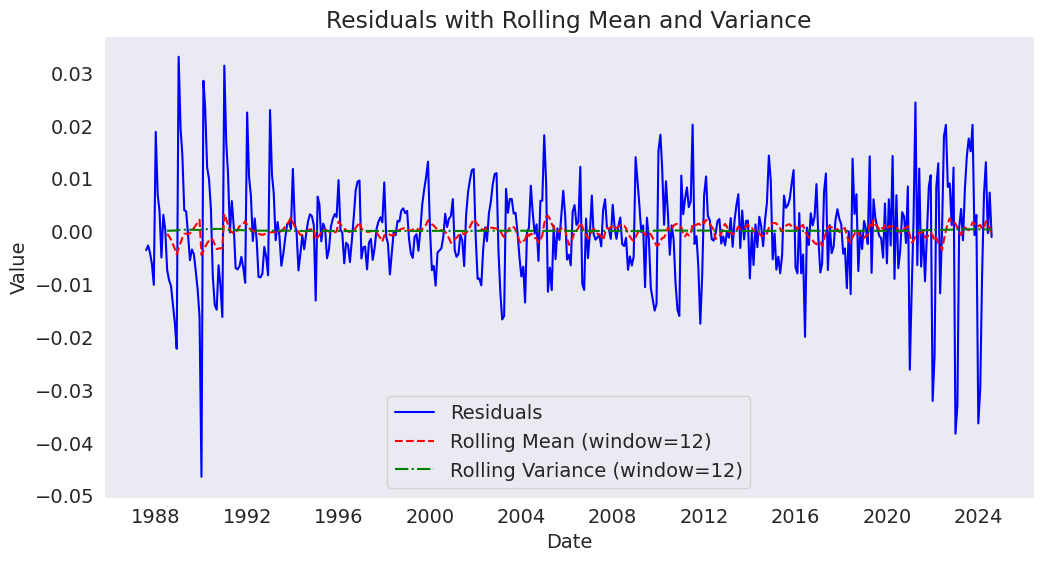

Identified Outliers in Residuals:
            log_residual
year_month              
1989-01-01      0.032992
1990-01-01     -0.046471
1990-02-01      0.028439
1991-01-01      0.031305
2022-01-01     -0.032135
2023-01-01     -0.038341
2023-02-01     -0.032845
2024-01-01     -0.036375
2024-02-01     -0.029774


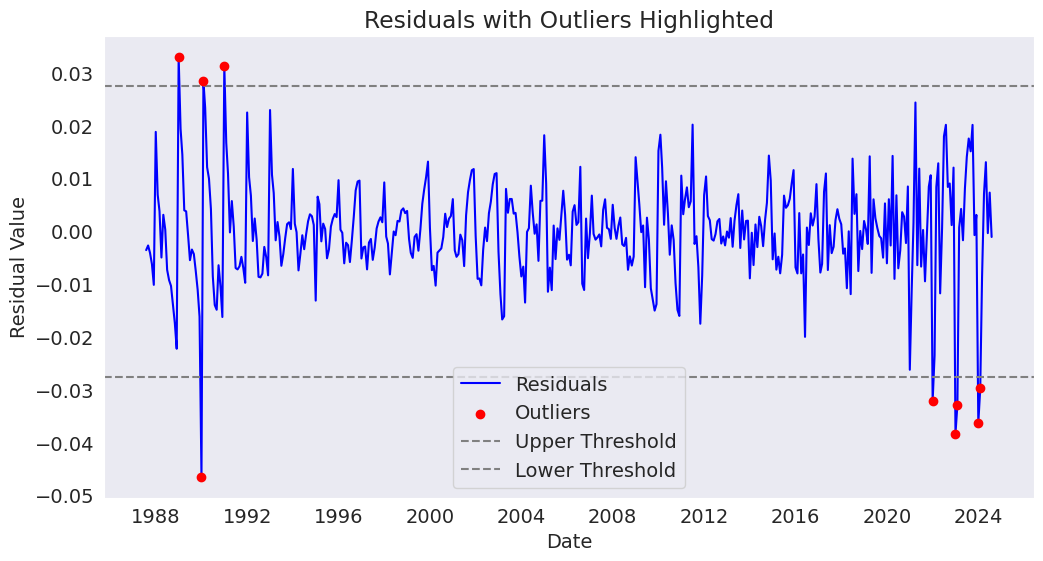

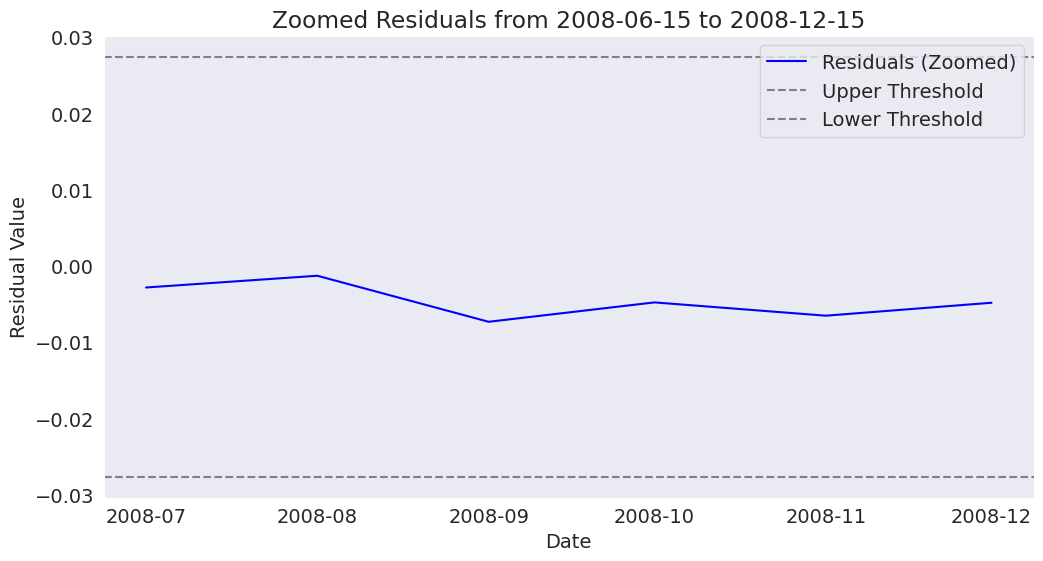

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt



# ---------------------------
# 1. Compute Rolling Statistics
# ---------------------------


window_size = 12


df2['rolling_mean'] = df2['log_residual'].rolling(window=window_size).mean()
df2['rolling_var'] = df2['log_residual'].rolling(window=window_size).var()

plt.figure(figsize=(12, 6))
plt.plot(df2.index, df2['log_residual'], label='Residuals', color='blue')
plt.plot(df2.index, df2['rolling_mean'], label=f'Rolling Mean (window={window_size})', color='red', linestyle='--')
plt.plot(df2.index, df2['rolling_var'], label=f'Rolling Variance (window={window_size})', color='green', linestyle='-.')
plt.title('Residuals with Rolling Mean and Variance')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.grid()
plt.show()

# ---------------------------
# 2. Identify Outliers in Residuals
# ---------------------------


resid_mean = df2['log_residual'].mean()
resid_std = df2['log_residual'].std()


upper_threshold = resid_mean + 3 * resid_std
lower_threshold = resid_mean - 3 * resid_std


df2['outlier'] = (df2['log_residual'] > upper_threshold) | (df2['log_residual'] < lower_threshold)


outliers = df2[df2['outlier']]
print("Identified Outliers in Residuals:")
print(outliers[['log_residual']])


plt.figure(figsize=(12, 6))
plt.plot(df2.index, df2['log_residual'], label='Residuals', color='blue')
plt.scatter(outliers.index, outliers['log_residual'], color='red', label='Outliers', zorder=5)
plt.axhline(upper_threshold, color='gray', linestyle='--', label='Upper Threshold')
plt.axhline(lower_threshold, color='gray', linestyle='--', label='Lower Threshold')
plt.title('Residuals with Outliers Highlighted')
plt.xlabel('Date')
plt.ylabel('Residual Value')
plt.legend()
plt.grid()
plt.show()

# ---------------------------
# 3. Zoom In on Specific Time Period for Detailed Analysis
# ---------------------------

zoom_start = '2008-06-15'
zoom_end = '2008-12-15'


df_zoom = df2.loc[zoom_start:zoom_end]


plt.figure(figsize=(12, 6))
plt.plot(df_zoom.index, df_zoom['log_residual'], label='Residuals (Zoomed)', color='blue')
plt.axhline(upper_threshold, color='gray', linestyle='--', label='Upper Threshold')
plt.axhline(lower_threshold, color='gray', linestyle='--', label='Lower Threshold')
plt.title(f'Zoomed Residuals from {zoom_start} to {zoom_end}')
plt.xlabel('Date')
plt.ylabel('Residual Value')
plt.legend()
plt.grid()
plt.show()


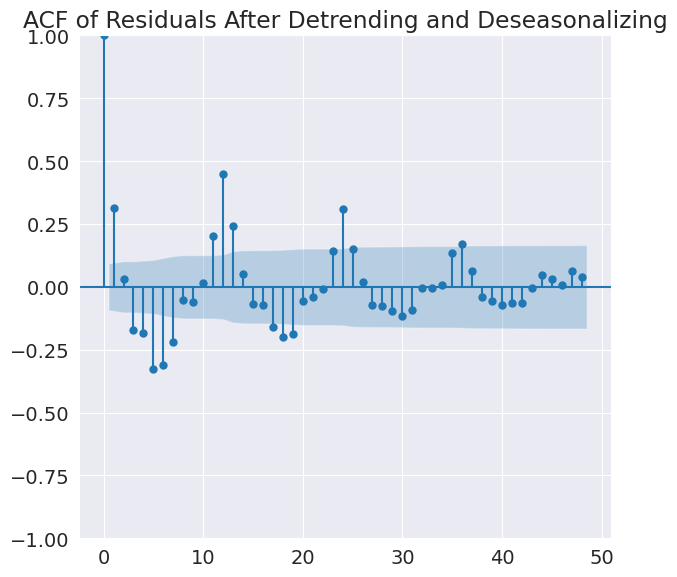

In [ ]:
#ACF and PACF for log residual data
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plot_acf(df2['log_residual'].dropna(), lags=48, ax=plt.gca())
plt.title('ACF of Residuals After Detrending and Deseasonalizing')


plt.tight_layout()
plt.show()



/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                      
Dep. Variable:                               data   No. Observations:                  457
Model:             SARIMAX(1, 0, 1)x(1, 1, 1, 12)   Log Likelihood               -1065.465
Date:                            Sun, 13 Apr 2025   AIC                           2140.929
Time:                                    06:01:26   BIC                           2161.260
Sample:                                02-01-1987   HQIC                          2148.956
                                     - 02-01-2025                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.0010      0.003    390.711      0.000       0.996       1.006
ma.L1         -0.4338      0.034   

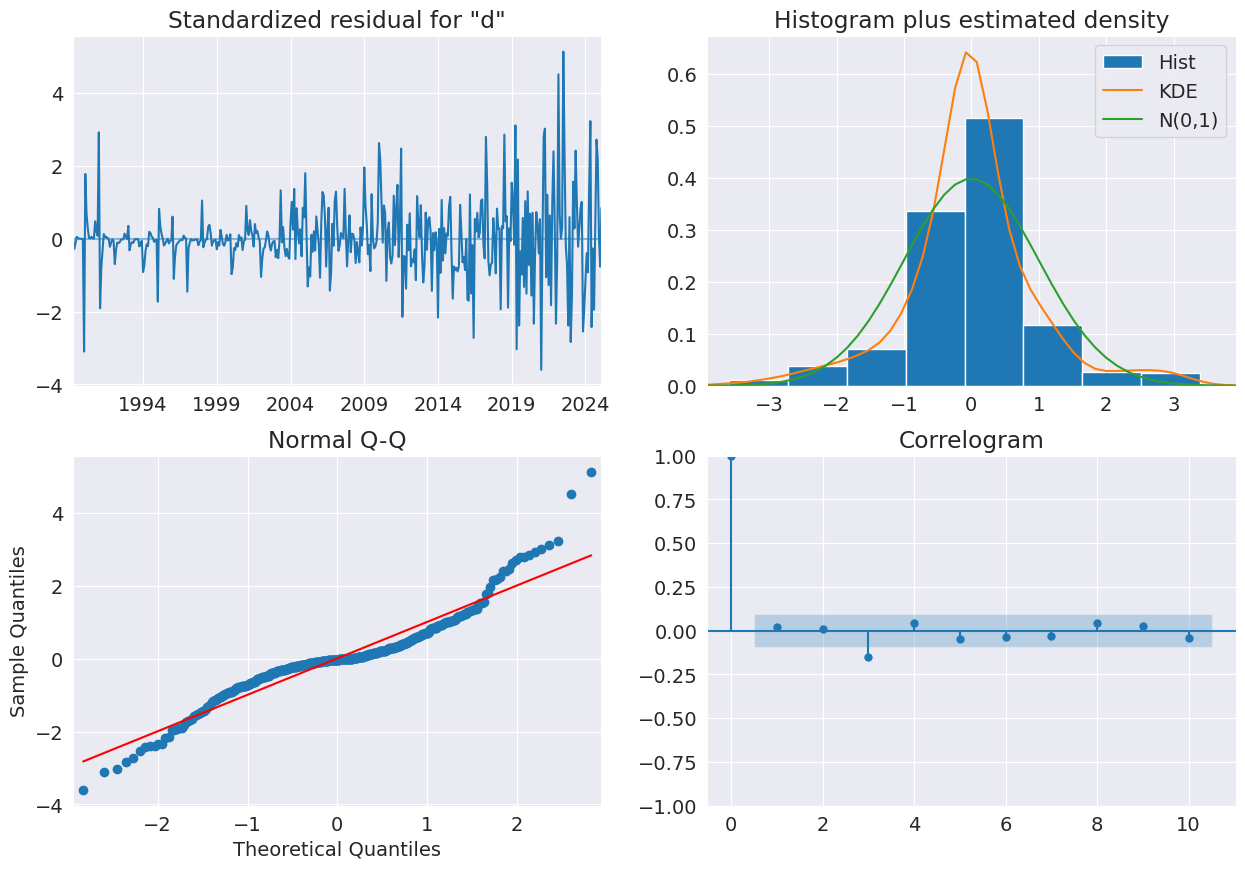

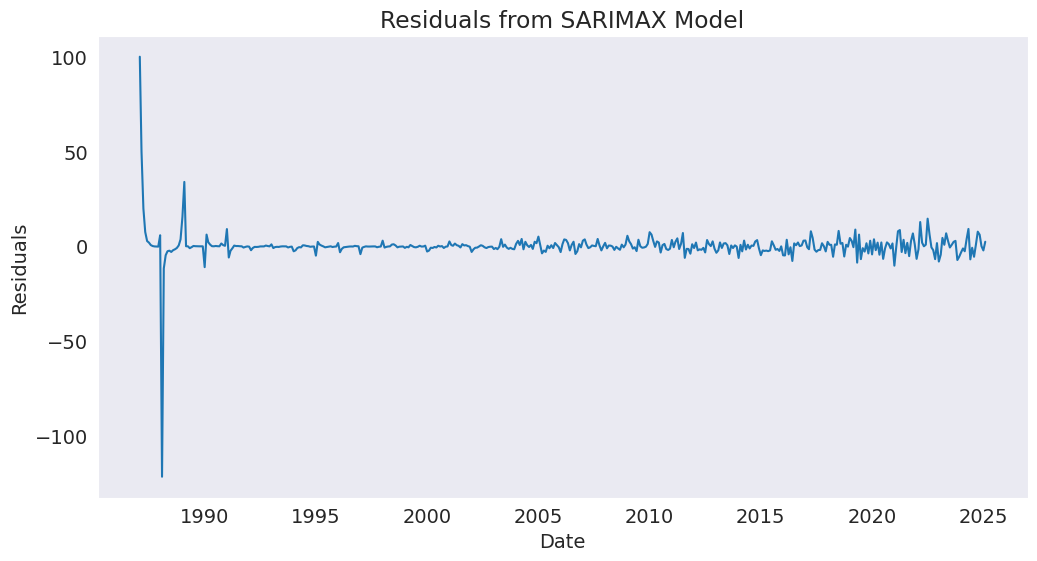

<Figure size 1200x600 with 0 Axes>

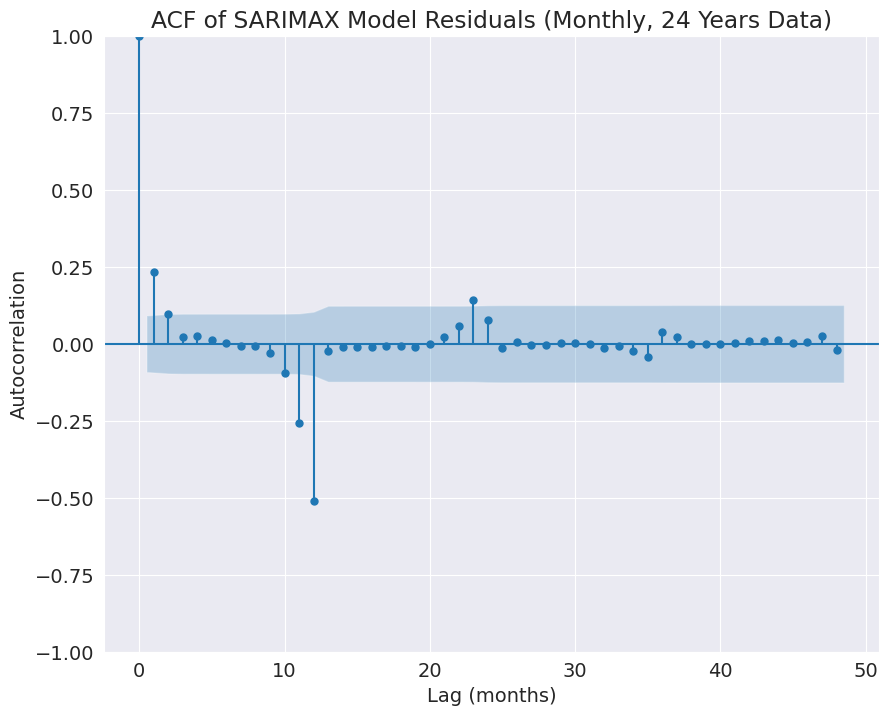

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf
import statsmodels.api as sm



# ---------------------------
# 1. Fit a SARIMAX Model
# ---------------------------

model = SARIMAX(df2['data'],
                order=(1, 0, 1),
                seasonal_order=(1, 1, 1, 12),
                enforce_stationarity=False,
                enforce_invertibility=False)

model_fit = model.fit(disp=False)
print(model_fit.summary())

# ---------------------------
# 2. Diagnostic Plots
# ---------------------------

model_fit.plot_diagnostics(figsize=(15, 10))
plt.show()

# ---------------------------
# 3. Check Residuals and Their ACF
# ---------------------------

residuals = model_fit.resid
plt.figure(figsize=(12, 6))
plt.plot(residuals)
plt.title('Residuals from SARIMAX Model')
plt.xlabel('Date')
plt.ylabel('Residuals')
plt.grid()
plt.show()


plt.figure(figsize=(12, 6))
plot_acf(residuals, lags=48, alpha=0.05)
plt.title('ACF of SARIMAX Model Residuals (Monthly, 24 Years Data)')
plt.xlabel('Lag (months)')
plt.ylabel('Autocorrelation')
plt.show()


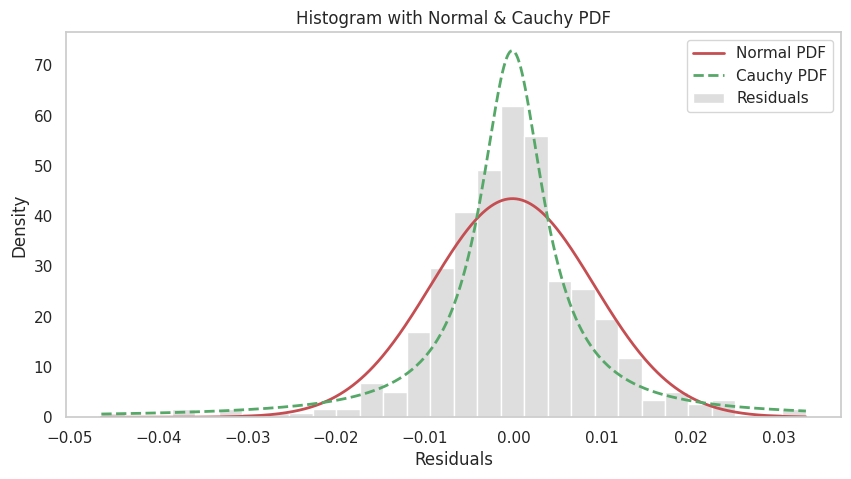

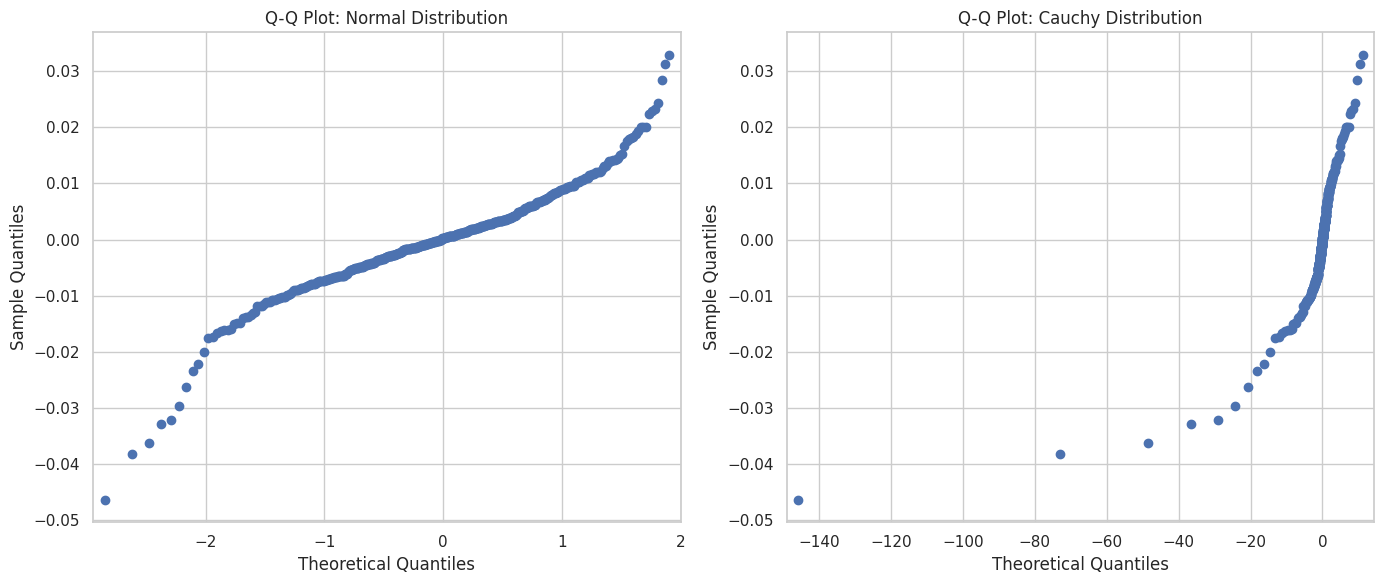

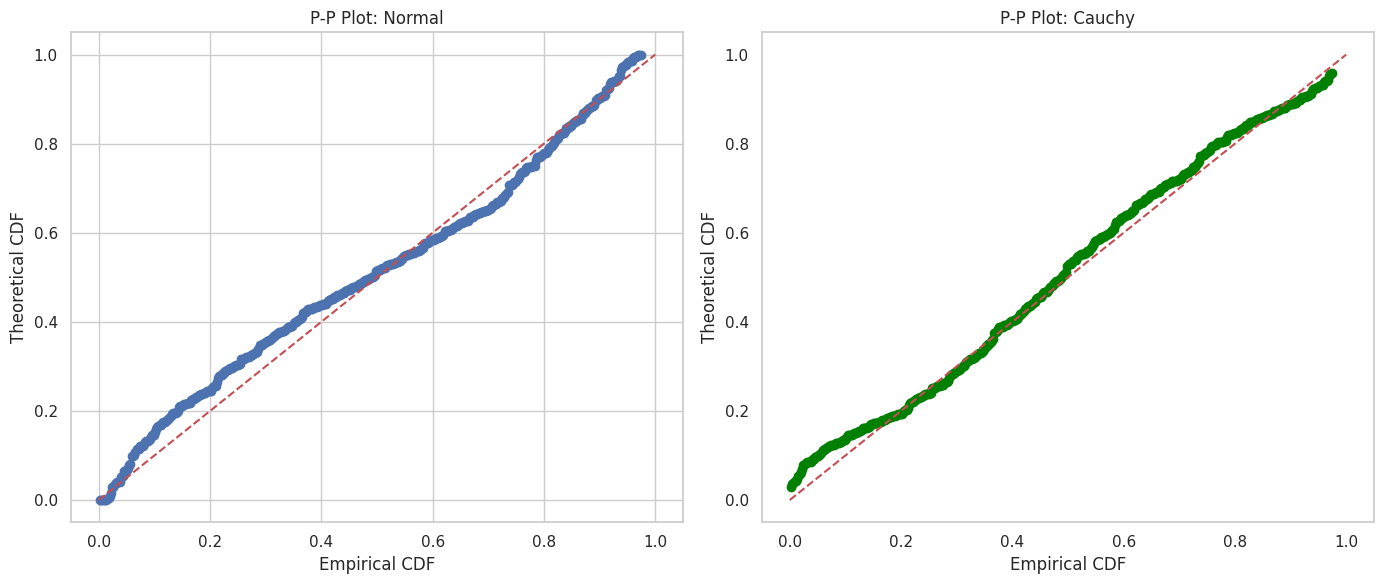

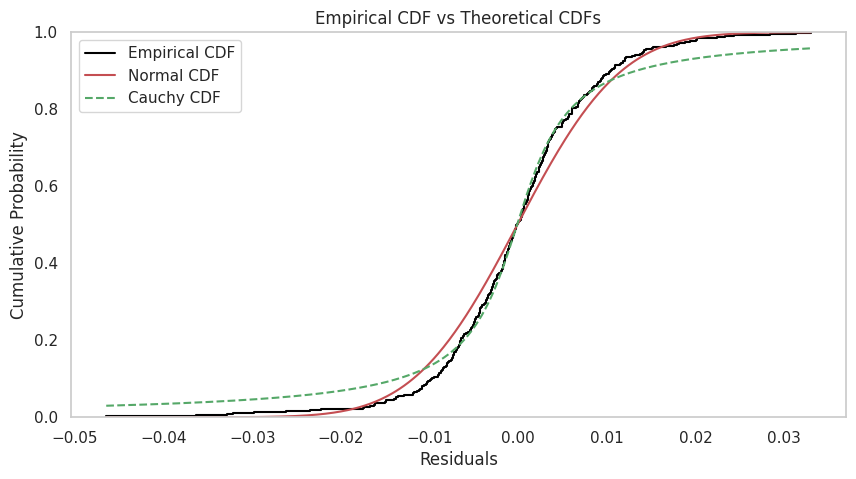

K-S Test for Normal: KstestResult(statistic=np.float64(0.06959205122291456), pvalue=np.float64(0.025575600712753), statistic_location=np.float64(0.003931494819612953), statistic_sign=np.int8(1))
K-S Test for Cauchy: KstestResult(statistic=np.float64(0.05583698818959265), pvalue=np.float64(0.120071430836872), statistic_location=np.float64(-0.0175252839177734), statistic_sign=np.int8(-1))


In [ ]:
import seaborn as sns
from scipy import stats
import matplotlib.pyplot as plt


residuals = df2['log_residual']
sns.set(style="whitegrid")


residuals_clean = residuals[np.isfinite(residuals)]


mean, std = residuals_clean.mean(), residuals_clean.std()
params_cauchy = stats.cauchy.fit(residuals_clean)


xmin, xmax = residuals_clean.min(), residuals_clean.max()
x = np.linspace(xmin, xmax, 500)

# -------------------------------
# 1. Histogram with PDF overlays
# -------------------------------
plt.figure(figsize=(10, 5))
sns.histplot(residuals, kde=False, bins=30, stat="density", color='lightgray', label="Residuals")
plt.plot(x, stats.norm.pdf(x, mean, std), 'r-', lw=2, label='Normal PDF')
plt.plot(x, stats.cauchy.pdf(x, *params_cauchy), 'g--', lw=2, label='Cauchy PDF')
plt.title("Histogram with Normal & Cauchy PDF")
plt.xlabel("Residuals")
plt.ylabel("Density")
plt.legend()
plt.grid()
plt.show()

# -------------------------------
# 2. Q-Q Plots
# -------------------------------
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

sm.qqplot(residuals, line='s', dist=stats.norm, ax=ax[0])
ax[0].set_title('Q-Q Plot: Normal Distribution')

sm.qqplot(residuals, line='s', dist=stats.cauchy, ax=ax[1])
ax[1].set_title('Q-Q Plot: Cauchy Distribution')

plt.tight_layout()
plt.show()

# -------------------------------
# 3. P-P Plots
# -------------------------------
fig, ax = plt.subplots(1, 2, figsize=(14, 6))
residuals_sorted = np.sort(residuals)
n = len(residuals_sorted)
p_empirical = np.arange(1, n + 1) / n

p_normal = stats.norm.cdf(residuals_sorted, mean, std)
p_cauchy = stats.cauchy.cdf(residuals_sorted, *params_cauchy)

ax[0].plot(p_empirical, p_normal, 'o', label="P-P Normal")
ax[0].plot([0, 1], [0, 1], 'r--')
ax[0].set_title('P-P Plot: Normal')
ax[0].set_xlabel("Empirical CDF")
ax[0].set_ylabel("Theoretical CDF")

ax[1].plot(p_empirical, p_cauchy, 'o', label="P-P Cauchy", color='green')
ax[1].plot([0, 1], [0, 1], 'r--')
ax[1].set_title('P-P Plot: Cauchy')
ax[1].set_xlabel("Empirical CDF")
ax[1].set_ylabel("Theoretical CDF")

plt.tight_layout()
plt.grid()
plt.show()

# -------------------------------
# 4. CDF Overlay with Empirical CDF
# -------------------------------
plt.figure(figsize=(10, 5))
sns.ecdfplot(residuals, label='Empirical CDF', color='black')
plt.plot(x, stats.norm.cdf(x, mean, std), 'r-', label='Normal CDF')
plt.plot(x, stats.cauchy.cdf(x, *params_cauchy), 'g--', label='Cauchy CDF')
plt.title("Empirical CDF vs Theoretical CDFs")
plt.xlabel("Residuals")
plt.ylabel("Cumulative Probability")
plt.legend()
plt.grid()
plt.show()

from scipy.stats import kstest

# Kolmogorov-Smirnov Test
ks_norm = kstest(residuals_clean, 'norm', args=(mean, std))
ks_cauchy = kstest(residuals_clean, 'cauchy', args=params_cauchy)

print("K-S Test for Normal:", ks_norm)
print("K-S Test for Cauchy:", ks_cauchy)


<Figure size 700x600 with 0 Axes>

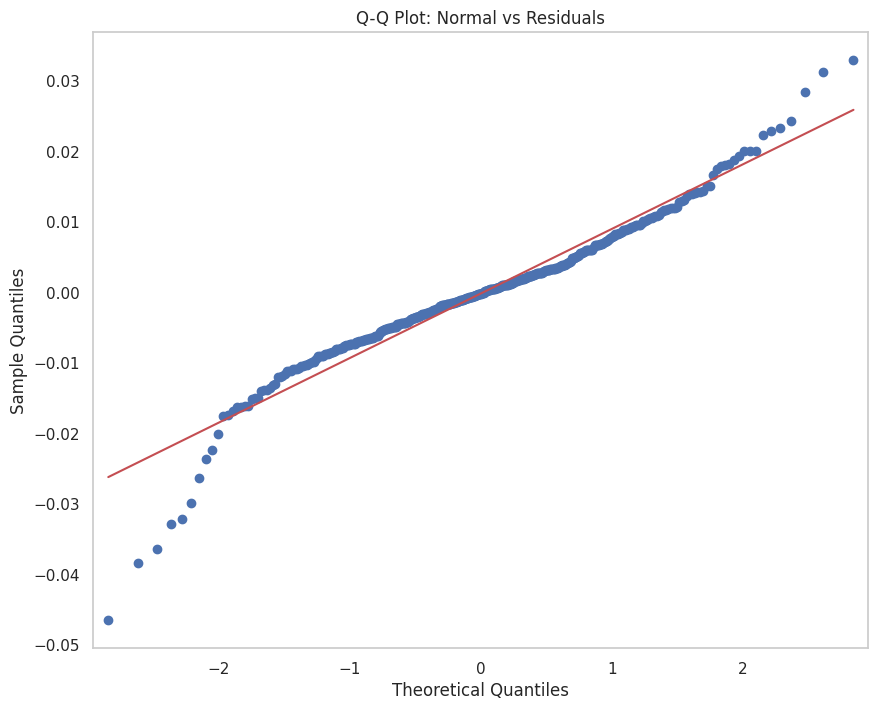

<Figure size 700x600 with 0 Axes>

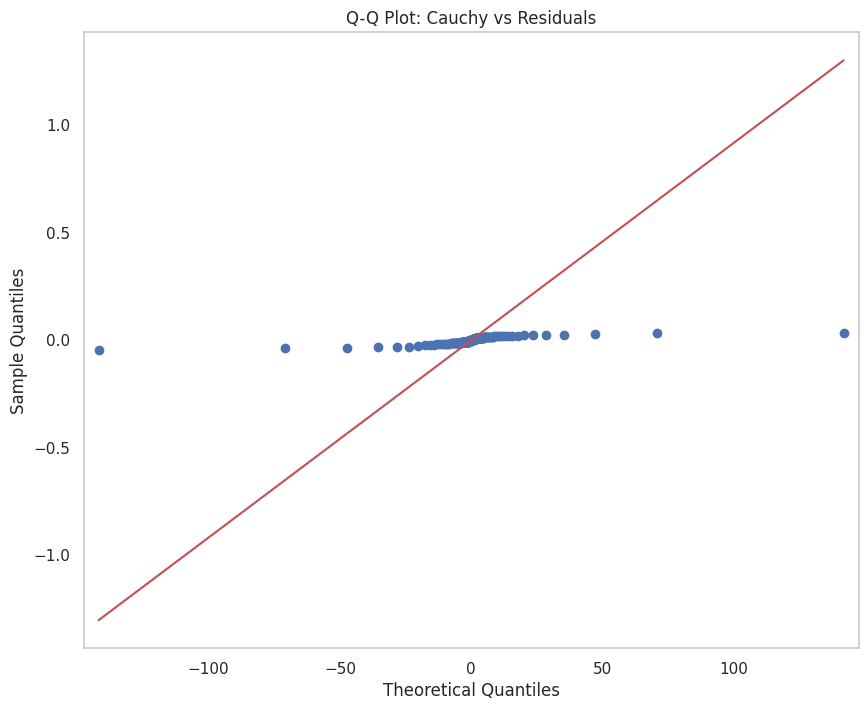

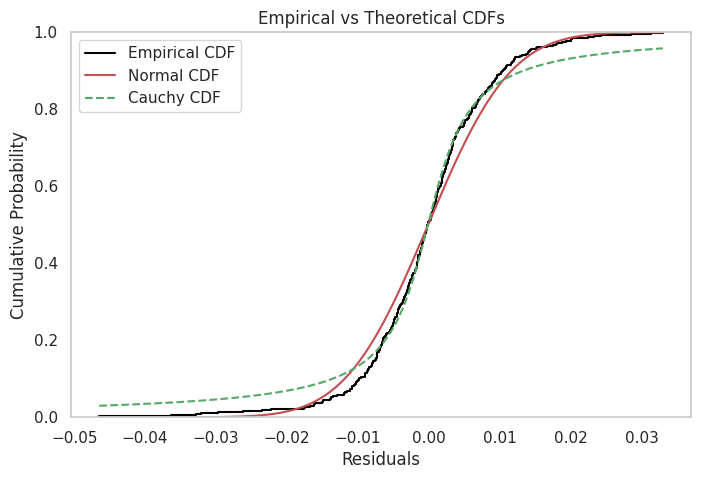

Kolmogorov-Smirnov Test Results:
Normal: statistic = 0.0696, p-value = 0.0256
Cauchy: statistic = 0.0558, p-value = 0.1201


In [ ]:
import seaborn as sns
from scipy import stats
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm


residuals = df2['log_residual']
residuals_clean = residuals[np.isfinite(residuals)]


mean, std = residuals_clean.mean(), residuals_clean.std()
params_cauchy = stats.cauchy.fit(residuals_clean)


plt.figure(figsize=(7, 6))
sm.qqplot(residuals_clean, line='s', dist=stats.norm, label='Normal')
plt.title('Q-Q Plot: Normal vs Residuals')
plt.grid()
plt.show()

plt.figure(figsize=(7, 6))
sm.qqplot(residuals_clean, line='s', dist=stats.cauchy, label='Cauchy')
plt.title('Q-Q Plot: Cauchy vs Residuals')
plt.grid()
plt.show()


x = np.linspace(residuals_clean.min(), residuals_clean.max(), 500)
plt.figure(figsize=(8, 5))
sns.ecdfplot(residuals_clean, label='Empirical CDF', color='black')
plt.plot(x, stats.norm.cdf(x, mean, std), 'r-', label='Normal CDF')
plt.plot(x, stats.cauchy.cdf(x, *params_cauchy), 'g--', label='Cauchy CDF')
plt.title("Empirical vs Theoretical CDFs")
plt.xlabel("Residuals")
plt.ylabel("Cumulative Probability")
plt.legend()
plt.grid()
plt.show()


from scipy.stats import kstest
ks_norm = kstest(residuals_clean, 'norm', args=(mean, std))
ks_cauchy = kstest(residuals_clean, 'cauchy', args=params_cauchy)

print("Kolmogorov-Smirnov Test Results:")
print("Normal: statistic = {:.4f}, p-value = {:.4f}".format(ks_norm.statistic, ks_norm.pvalue))
print("Cauchy: statistic = {:.4f}, p-value = {:.4f}".format(ks_cauchy.statistic, ks_cauchy.pvalue))


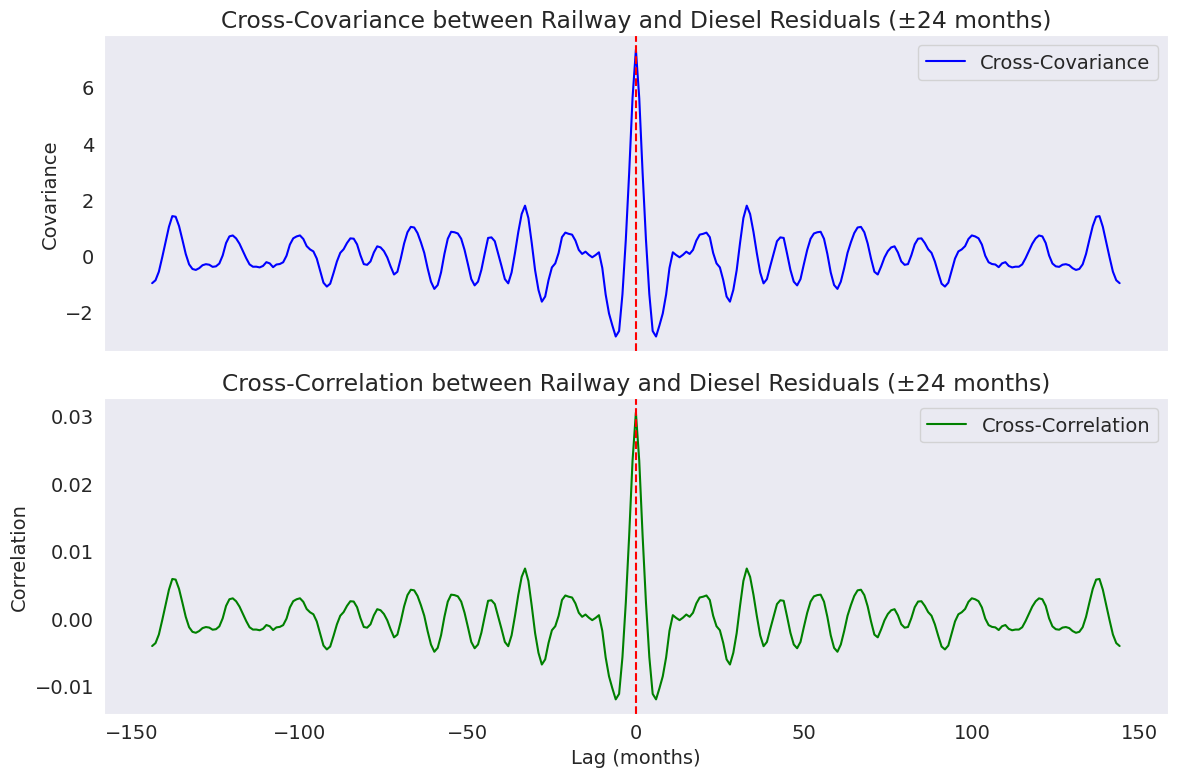

Pearson Correlation (lag = 0): 1.0000


In [ ]:
#Cross - Correlation of the Diesel and Railways
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr


df.index = pd.to_datetime(df.index)
df2.index = pd.to_datetime(df2.index)

df.index = df.index.to_period('M').to_timestamp()
df2.index = df2.index.to_period('M').to_timestamp()


start_date = "2002-01-01"
end_date = "2021-12-31"

railway_residuals = df2['poly_residual'].loc[start_date:end_date]
diesel_residuals = df['residual'].loc[start_date:end_date]


filtered_df = pd.DataFrame({
    'railway': railway_residuals,
    'diesel': diesel_residuals
}).dropna()

railway_residuals = filtered_df['railway']
diesel_residuals = filtered_df['diesel']


cross_cov = np.correlate(diesel_residuals,railway_residuals,  mode='full')
lags_full = np.arange(-len(diesel_residuals) + 1, len(diesel_residuals))
cross_corr = cross_cov / len(diesel_residuals)


lag_limit = 144
center_idx = len(cross_corr) // 2
start_idx = center_idx - lag_limit
end_idx = center_idx + lag_limit + 1

lags = lags_full[start_idx:end_idx]
cross_cov_limited = cross_cov[start_idx:end_idx]
cross_corr_limited = cross_corr[start_idx:end_idx]


fig, ax = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

ax[0].plot(lags, cross_cov_limited, label='Cross-Covariance', color='blue')
ax[0].axvline(0, color='red', linestyle='--')
ax[0].set_title("Cross-Covariance between Railway and Diesel Residuals (±24 months)")
ax[0].set_ylabel("Covariance")
ax[0].legend()
ax[0].grid()

ax[1].plot(lags, cross_corr_limited, label='Cross-Correlation', color='green')
ax[1].axvline(0, color='red', linestyle='--')
ax[1].set_title("Cross-Correlation between Railway and Diesel Residuals (±24 months)")
ax[1].set_xlabel("Lag (months)")
ax[1].set_ylabel("Correlation")
ax[1].legend()
ax[1].grid()

plt.tight_layout()
plt.show()


pearson_corr, _ = pearsonr(railway_residuals, diesel_residuals)
print(f"Pearson Correlation (lag = 0): {pearson_corr:.4f}")


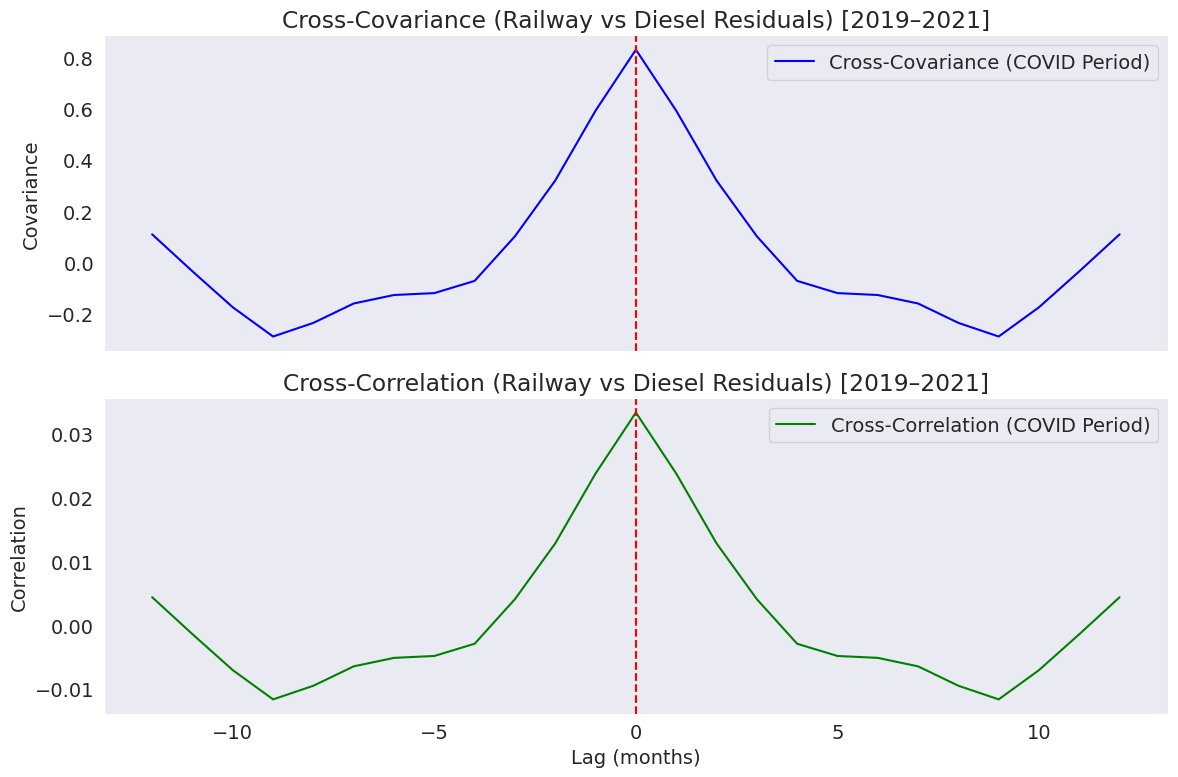

Pearson Correlation (lag = 0) during COVID-19: 1.0000


In [ ]:
# COVID 19 period's Cross Correlation
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr


df.index = pd.to_datetime(df.index)
df2.index = pd.to_datetime(df2.index)

df.index = df.index.to_period('M').to_timestamp()
df2.index = df2.index.to_period('M').to_timestamp()


covid_start = "2019-12-01"
covid_end = "2021-12-31"

railway_residuals = df2['poly_residual'].loc[covid_start:covid_end]
diesel_residuals = df['residual'].loc[covid_start:covid_end]


filtered_df = pd.DataFrame({
    'railway': railway_residuals,
    'diesel': diesel_residuals
}).dropna()

railway_residuals = filtered_df['railway']
diesel_residuals = filtered_df['diesel']


cross_cov = np.correlate(diesel_residuals,railway_residuals,  mode='full')
lags_full = np.arange(-len(diesel_residuals) + 1, len(diesel_residuals))
cross_corr = cross_cov / len(diesel_residuals)


lag_limit = 12
center_idx = len(cross_corr) // 2
start_idx = center_idx - lag_limit
end_idx = center_idx + lag_limit + 1

lags = lags_full[start_idx:end_idx]
cross_cov_limited = cross_cov[start_idx:end_idx]
cross_corr_limited = cross_corr[start_idx:end_idx]


fig, ax = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

ax[0].plot(lags, cross_cov_limited, label='Cross-Covariance (COVID Period)', color='blue')
ax[0].axvline(0, color='red', linestyle='--')
ax[0].set_title("Cross-Covariance (Railway vs Diesel Residuals) [2019–2021]")
ax[0].set_ylabel("Covariance")
ax[0].legend()
ax[0].grid()

ax[1].plot(lags, cross_corr_limited, label='Cross-Correlation (COVID Period)', color='green')
ax[1].axvline(0, color='red', linestyle='--')
ax[1].set_title("Cross-Correlation (Railway vs Diesel Residuals) [2019–2021]")
ax[1].set_xlabel("Lag (months)")
ax[1].set_ylabel("Correlation")
ax[1].legend()
ax[1].grid()

plt.tight_layout()
plt.show()


pearson_corr, _ = pearsonr(railway_residuals, diesel_residuals)
print(f"Pearson Correlation (lag = 0) during COVID-19: {pearson_corr:.4f}")
